# Formula 1 Lap Time Prediction

## Bahrain Grand Prix (2022-2025): Temporal Analysis and Predictive Modeling

This notebook documents the complete analysis pipeline for the Bahrain GP, covering multi-season data consolidation, exploratory diagnostics, feature transformations, temporal validation, and comparison between Linear Regression and XGBoost.

---

## 1. Initial Setup: Imports and Environment

The first cell loads the scientific Python stack, visualization libraries, FastF1 utilities, and modeling dependencies used throughout the notebook.

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import scipy.stats as stats
import statsmodels.api as sm
import xgboost as xgb
import optuna
import shap
from sklearn.ensemble import RandomForestRegressor

CACHE_DIR = './fastf1_cache'
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
print(f"FastF1 cache enabled at: {os.path.abspath(CACHE_DIR)}")

BASE_PLOT_DIR = './f1_plots'
if not os.path.exists(BASE_PLOT_DIR):
    os.makedirs(BASE_PLOT_DIR)
print(f"Base directory for saving plots: {os.path.abspath(BASE_PLOT_DIR)}")

C:\Users\mpoli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FastF1 cache enabled at: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\Notebooks\fastf1_cache
Base directory for saving plots: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\Notebooks\f1_plots


---

## 2. Multi-Season Data Extraction (2022-2025)

### Objective

Build a longitudinal race dataset for the **Bahrain Grand Prix** across multiple seasons, combining lap timing, tyre usage, weather information, driver/team identifiers, and race results.

The circuit is located in **Sakhir, Bahrain**.

In [2]:
start_year_analysis = 2022
end_year_analysis = 2026
target_gp_name = 'Bahrain Grand Prix'
laps_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Bahrain\Race\Laps'
weather_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Bahrain\Race\Weather'
safe_gp_name = target_gp_name.lower().replace(' ', '_')

all_laps_data_by_year = {}
all_weather_data_by_year = {}
all_results_data_by_year = {}

print(f"--- Loading local data for {target_gp_name} ---")

for year in range(start_year_analysis, end_year_analysis):
    laps_file = os.path.join(laps_dir, f"{safe_gp_name}_laps_{year}.csv")
    weather_file = os.path.join(weather_dir, f"{safe_gp_name}_weather_{year}.csv")
    
    if os.path.exists(laps_file) and os.path.exists(weather_file):
        print(f"  [CSV] Loading and converting season {year}...")
        
        df_laps = pd.read_csv(laps_file)
        df_weather = pd.read_csv(weather_file)
        
        df_laps['Time'] = pd.to_timedelta(df_laps['Time'])
        df_weather['Time'] = pd.to_timedelta(df_weather['Time'])
        
        if 'LapTime' in df_laps.columns:
            df_laps['LapTime'] = pd.to_timedelta(df_laps['LapTime'])
        
        df_laps = df_laps.sort_values('Time')
        df_weather = df_weather.sort_values('Time')
        
        all_laps_data_by_year[year] = df_laps
        all_weather_data_by_year[year] = df_weather
    else:
        print(f"  [!] Files from {year} not founded in '{laps_dir}'.")

print("\nMerging multiple years data...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        laps_df = all_laps_data_by_year[year].copy()
        weather_df = all_weather_data_by_year[year].copy()
        
        laps_df['Year'] = year
        weather_df['Year'] = year
        
        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)

if not lista_de_dataframes_anuais_laps:
    print("No data found to process.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    
    cols_to_check = ['LapTime_seconds', 'TyreLife']
    if 'pirelliCompound' in clean_laps_df.columns:
        cols_to_check.append('pirelliCompound')
        
    clean_laps_df.dropna(subset=cols_to_check, inplace=True)
    clean_laps_df['Year'] = clean_laps_df['Year'].astype('category')

    print(f"Success! Total of {len(clean_laps_df)} clean laps ready for weather merging.")

--- Loading local data for Bahrain Grand Prix ---
  [CSV] Loading and converting season 2022...
  [CSV] Loading and converting season 2023...
  [CSV] Loading and converting season 2024...
  [CSV] Loading and converting season 2025...

Merging multiple years data...
Success! Total of 3783 clean laps ready for weather merging.


---

## 3. Data Consolidation and Cleaning

### Quality Filtering with `IsAccurate`

The first quality gate is the FastF1 `IsAccurate` flag. This removes laps with non-representative race timing, such as laps affected by missing timing sectors or unreliable telemetry.

After loading yearly files, lap and weather records are aligned and consolidated into a single modeling table.

In [3]:
print("Data loading and cleaning...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        print(f"Loading data for {target_gp_name} {year}...")
        laps_df = all_laps_data_by_year[year]
        weather_df = all_weather_data_by_year[year]
        weather_df['Year'] = year
        laps_df['Year'] = year

        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)
    else:
        print(f"No data for {target_gp_name} {year}.")

if not lista_de_dataframes_anuais_laps:
    print("No data found for the selected year range. Ending analysis.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    print(f"\nData from {len(lista_de_dataframes_anuais_laps)} seasons successfully combined!")
    print(f"Total of {len(combined_laps_df)} laps loaded.")
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    clean_laps_df.dropna(subset=['LapTime_seconds', 'TyreLife', 'pirelliCompound'], inplace=True)

    print(f"Analyzing {len(clean_laps_df)} clean laps from all seasons.")



    clean_laps_df['Year'] = clean_laps_df['Year'].astype('category')

    print(f"Total of {len(clean_laps_df)} clean laps for analysis.")

if not lista_de_dataframes_anuais_weather:
    print("No weather data found for the selected year range. Ending analysis.")
else:
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    print(f"Total of {len(combined_weather_df)} registros meteorológicos carregados.")
    print(f"\nData from {len(lista_de_dataframes_anuais_weather)} seasons successfully combined!")

Data loading and cleaning...
Loading data for Bahrain Grand Prix 2022...
Loading data for Bahrain Grand Prix 2023...
Loading data for Bahrain Grand Prix 2024...
Loading data for Bahrain Grand Prix 2025...

Data from 4 seasons successfully combined!
Total of 4438 laps loaded.
Analyzing 3783 clean laps from all seasons.
Total of 3783 clean laps for analysis.
Total of 639 registros meteorológicos carregados.

Data from 4 seasons successfully combined!


---

## 4. Feature Engineering

### 4.1 Autoregressive History (`LapTime_prev`)

We create an immediate-history feature inside each driver stint:

$$\text{LapTime\_prev}_{i} = \text{LapTime\_seconds}_{i-1}$$

This feature captures short-term race pace continuity while respecting driver, year, and stint boundaries.

In [4]:
clean_laps_df = clean_laps_df.sort_values(['Year','Driver','Stint','LapNumber'])
clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)

combined_laps_df_filtered = clean_laps_df.sort_values('Time').reset_index(drop=True)

combined_weather_df = combined_weather_df.sort_values('Time').reset_index(drop=True)
combined_weather_df = combined_weather_df.sort_values('Year').reset_index(drop=True)


weather_df_filtered = combined_weather_df.copy()

combined_laps_df_filtered['Year'] = combined_laps_df_filtered['Year'].astype(int)
weather_df_filtered['Year'] = weather_df_filtered['Year'].astype(int)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)
weather_df_filtered = weather_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values('Time')
weather_df_filtered = weather_df_filtered.sort_values('Time')

seconds_margin = 60
laps_with_weather = pd.merge_asof(
    combined_laps_df_filtered,
    weather_df_filtered.drop_duplicates(subset=['Time', 'Year']),
    on='Time',
    by='Year',
    direction='backward',
    tolerance=pd.Timedelta(seconds=seconds_margin)
)

laps_with_weather['TempDelta'] = laps_with_weather['TrackTemp'] - laps_with_weather['AirTemp']

display(laps_with_weather['Team'].unique())
team_mapping = {
    'Alfa Romeo Racing': 'Kick Sauber',
    'Alfa Romeo': 'Kick Sauber',
    'Racing Point': 'Aston Martin',
    'Toro Rosso': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',
    'RB': 'Racing Bulls',
    'Renault': 'Alpine'
}

laps_with_weather['Team'] = laps_with_weather['Team'].replace(team_mapping)
display(laps_with_weather['Team'].unique())

C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\1357446950.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)


array(['McLaren', 'Mercedes', 'Ferrari', 'Alpine', 'Williams',
       'Red Bull Racing', 'Haas F1 Team', 'Aston Martin', 'Racing Bulls',
       'Kick Sauber', 'RB', 'AlphaTauri', 'Alfa Romeo'], dtype=object)

array(['McLaren', 'Mercedes', 'Ferrari', 'Alpine', 'Williams',
       'Red Bull Racing', 'Haas F1 Team', 'Aston Martin', 'Racing Bulls',
       'Kick Sauber'], dtype=object)

---

## 5. Outlier Detection and Removal

### Motivation

Even after `IsAccurate`, atypical laps can remain due to traffic, recovery laps, isolated mistakes, or race interruptions.

### Approach

Outlier filtering is based on the distribution of lap-to-lap differences. The goal is to remove extreme transitions while preserving representative race pace behavior.

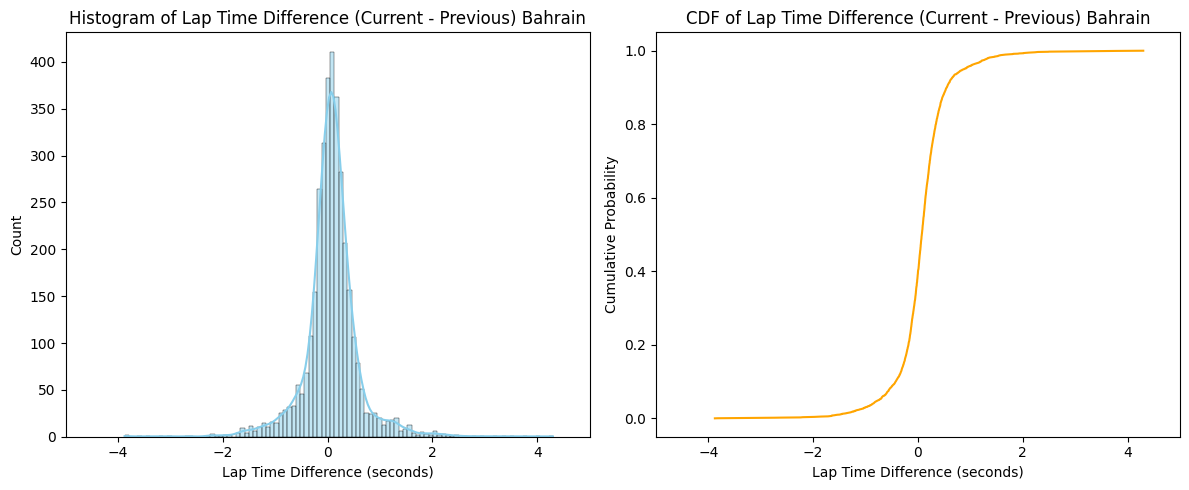

In [5]:
laps_with_weather['laps_diff'] = laps_with_weather['LapTime_seconds'] - laps_with_weather['LapTime_prev']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(laps_with_weather['laps_diff'].dropna(), kde=True, bins=100, color='skyblue')
plt.xlim(-5, 5)
plt.title('Histogram of Lap Time Difference (Current - Previous) Bahrain')
plt.xlabel('Lap Time Difference (seconds)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sorted_diff = np.sort(laps_with_weather['laps_diff'].dropna())
cdf_vals = np.arange(1, len(sorted_diff)+1) / len(sorted_diff)
plt.plot(sorted_diff, cdf_vals, color='orange')
plt.xlim(-5, 5)
plt.title('CDF of Lap Time Difference (Current - Previous) Bahrain')
plt.xlabel('Lap Time Difference (seconds)')
plt.ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()

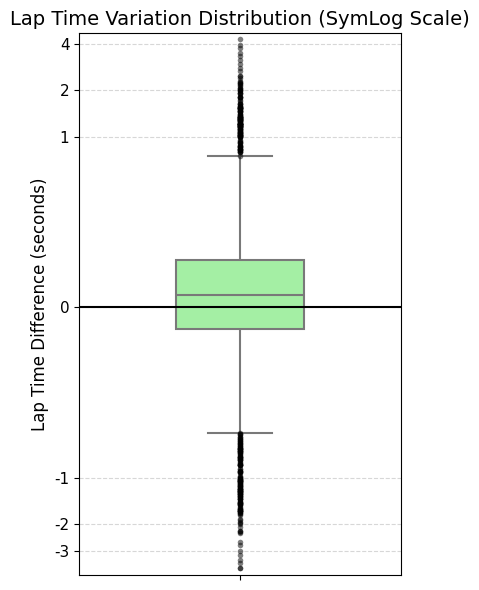

--- CUTOFF CANDIDATES ---
1. Conservative (Top 1%):  [-1.50s, 1.74s]
   (Removes only Pit Stops and severe SCs)

2. Statistical Standard (IQR): [-0.74s, 0.89s]
   (Most academically accepted for outliers)

3. Strict (Top 5%):     [-0.74s, 0.88s]
   (Keeps only very consistent laps)


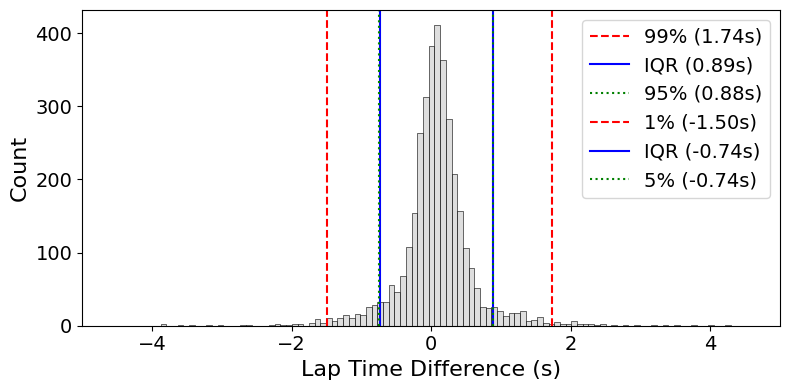

In [6]:
diff_data = laps_with_weather['laps_diff'].dropna()

plt.figure(figsize=(4, 6))
sns.boxplot(
    y=diff_data, 
    color='#98FB98', 
    width=0.4,       
    linewidth=1.5,   
    flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 4, "alpha": 0.5, "markeredgecolor": "none"}
)

plt.yscale('symlog', linthresh=1.0) 
custom_ticks = [-100, -50, -20, -10, -5, -2, -1, 0, 1, 2, 5, 10, 20, 50, 100]
min_val, max_val = diff_data.min(), diff_data.max()
visible_ticks = [t for t in custom_ticks if min_val <= t <= max_val]
if min_val < visible_ticks[0]: visible_ticks.insert(0, int(min_val))
if max_val > visible_ticks[-1]: visible_ticks.append(int(max_val))
plt.yticks(visible_ticks, labels=[str(t) for t in visible_ticks], fontsize=11)
plt.ylabel('Lap Time Difference (seconds)', fontsize=12)
plt.title('Lap Time Variation Distribution (SymLog Scale)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
plt.tight_layout()
plt.show()

p1 = np.percentile(diff_data, 1)
p99 = np.percentile(diff_data, 99)
Q1 = np.percentile(diff_data, 25)
Q3 = np.percentile(diff_data, 75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
p5 = np.percentile(diff_data, 5)
p95 = np.percentile(diff_data, 95)

print("--- CUTOFF CANDIDATES ---")
print(f"1. Conservative (Top 1%):  [{p1:.2f}s, {p99:.2f}s]")
print(f"   (Removes only Pit Stops and severe SCs)")
print(f"\n2. Statistical Standard (IQR): [{lower_iqr:.2f}s, {upper_iqr:.2f}s]")
print(f"   (Most academically accepted for outliers)")
print(f"\n3. Strict (Top 5%):     [{p5:.2f}s, {p95:.2f}s]")
print(f"   (Keeps only very consistent laps)")

plt.figure(figsize=(8, 4))
sns.histplot(diff_data, bins=100, kde=False, color='lightgray')
plt.xlim(-5, 5) 
plt.axvline(p99, color='red', linestyle='--', label=f'99% ({p99:.2f}s)')
plt.axvline(upper_iqr, color='blue', linestyle='-', label=f'IQR ({upper_iqr:.2f}s)')
plt.axvline(p95, color='green', linestyle=':', label=f'95% ({p95:.2f}s)')
plt.axvline(p1, color='red', linestyle='--', label=f'1% ({p1:.2f}s)')
plt.axvline(lower_iqr, color='blue', linestyle='-', label=f'IQR ({lower_iqr:.2f}s)')
plt.axvline(p5, color='green', linestyle=':', label=f'5% ({p5:.2f}s)')  
plt.xlabel('Lap Time Difference (s)', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.show()

In [7]:
try:
    stats_df_laps_diff = laps_with_weather.describe(include='all')

    features_interesse = [ 'laps_diff'
    ]

    skewness = laps_with_weather.skew(numeric_only=True)

    kurtosis = laps_with_weather.kurt(numeric_only=True)

    means = laps_with_weather.mean(numeric_only=True)
    stds = laps_with_weather.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)
    
    cv_series = pd.Series(cv, index=means.index)

    stats_df_laps_diff = stats_df_laps_diff[features_interesse]

    stats_df_laps_diff.loc['skewness'] = skewness
    stats_df_laps_diff.loc['kurtosis'] = kurtosis
    stats_df_laps_diff.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Stats ---")
    display(stats_df_laps_diff)
    

except Exception as e:
    print(f"An error has ocurred while calculating the statistics: {e}")


--- Stats ---


,laps_diff
count,3513.000000
unique,NaN
top,NaN
freq,NaN
mean,0.073447
std,0.541885
min,-3.876000
25%,-0.128000
50%,0.073000
75%,0.278000


In [8]:
mask_clean = (
    (laps_with_weather['laps_diff'] >= p5) &
    (laps_with_weather['laps_diff'] <= p95)
)

laps_cleaned = laps_with_weather[mask_clean].copy()

print(f"Original total: {len(laps_with_weather)}")
print(f"Total after filtering: {len(laps_cleaned)}")
print(f"Outliers removed (slow laps/Pit In): {len(laps_with_weather) - len(laps_cleaned)}")

Original total: 3783
Total after filtering: 3161
Outliers removed (slow laps/Pit In): 622


---

## 6. Exploratory Data Analysis (EDA): Univariate Distributions

### Objective

Inspect each variable independently before multivariate modeling. This helps validate data quality, identify skewness, detect long tails, and understand the empirical scale of the predictors used by the models.

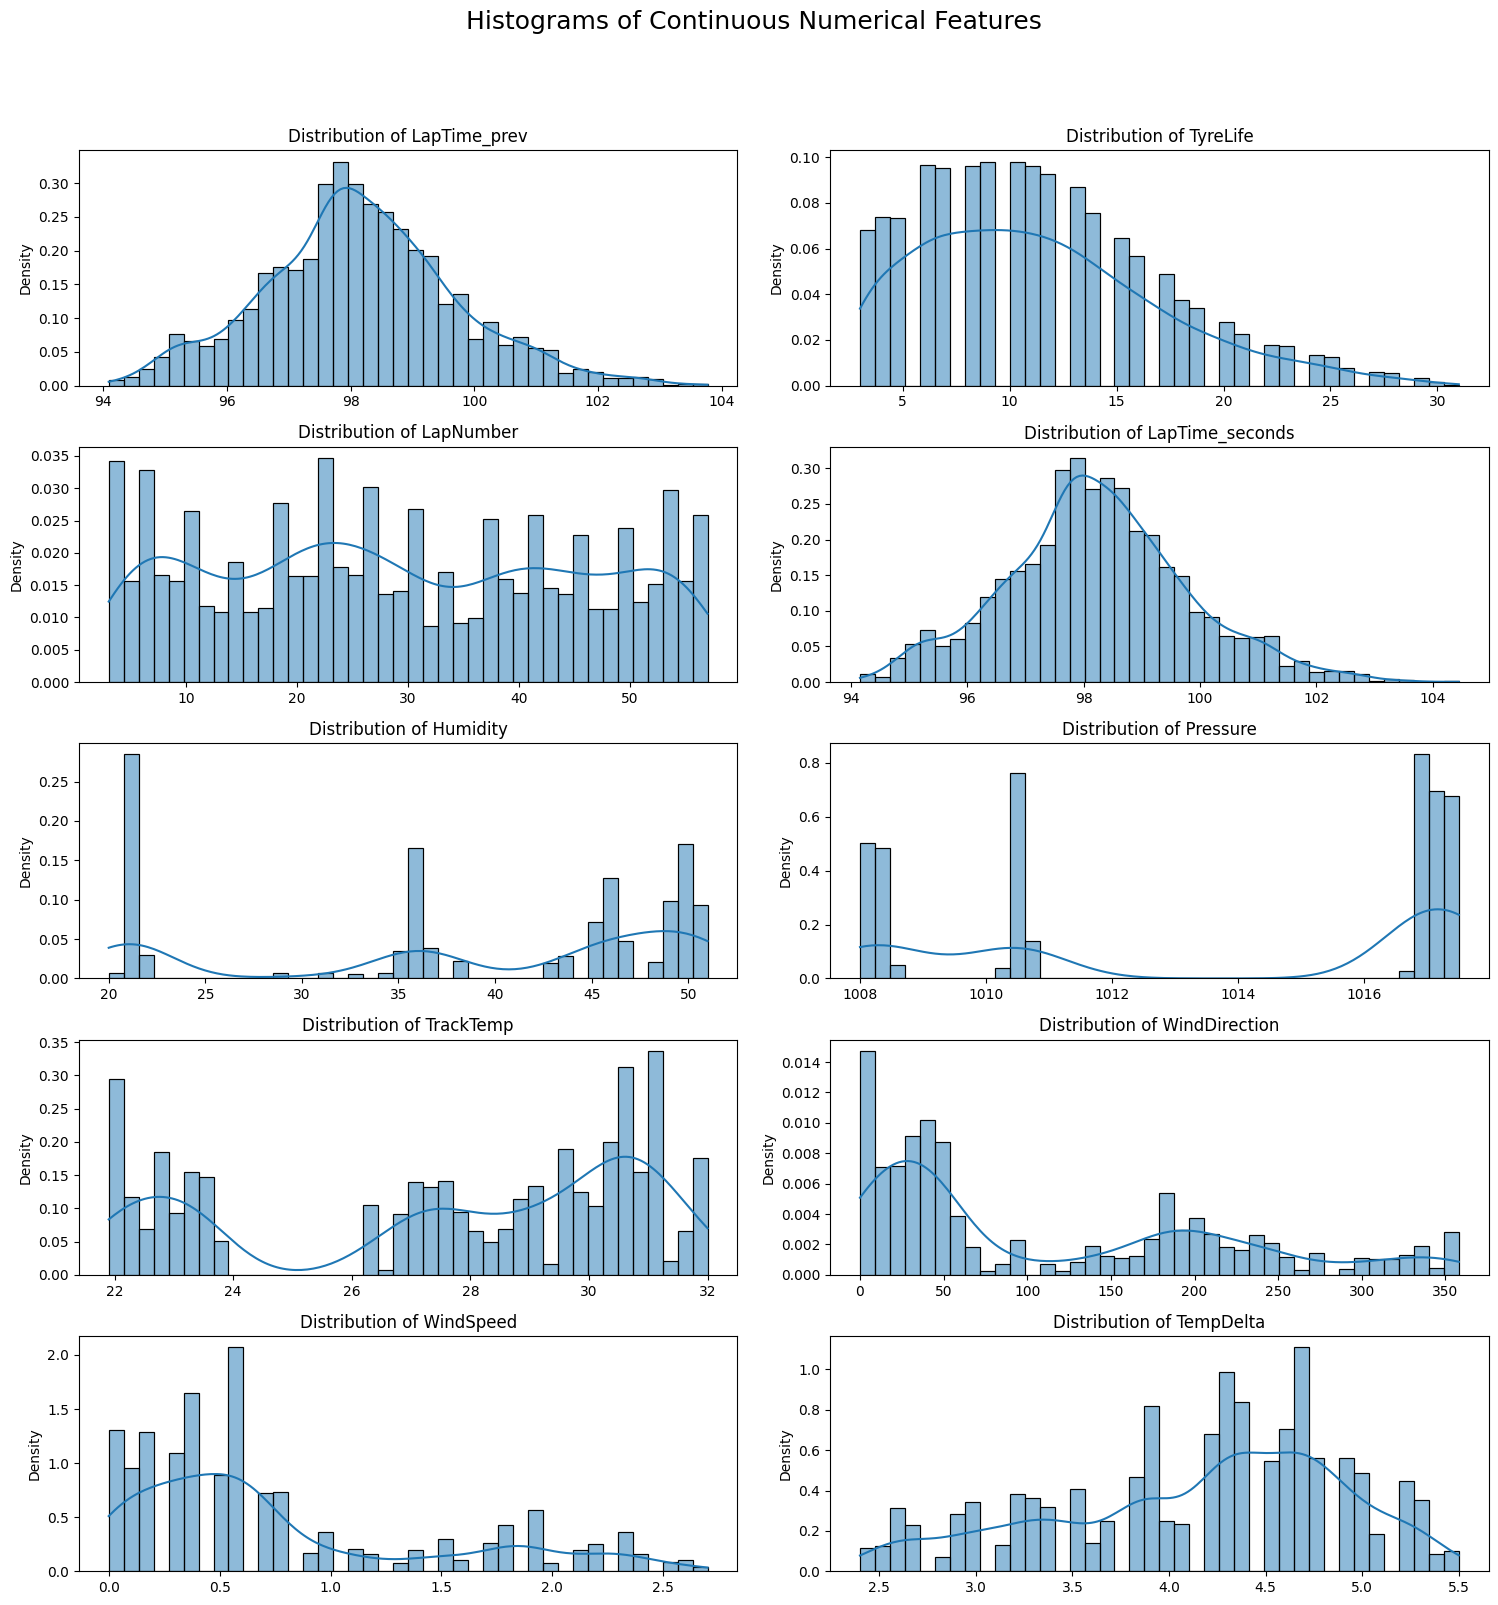

In [9]:
n_rows_cont = 5
n_cols_cont = 2
fig_cont, axes_cont = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cont = axes_cont.flatten()

continuous_cols = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds', 'Humidity', 
    'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
]

num_df = laps_cleaned[continuous_cols].copy()

for i, col in enumerate(continuous_cols):
    ax = flat_axes_cont[i]
    data_to_plot = num_df[col].dropna()
    
    if data_to_plot.empty:
        ax.set_title(f'{col} (No Data)')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.histplot(data_to_plot, kde=True, ax=ax, bins=40, stat="density")
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Density')

plt.suptitle('Histograms of Continuous Numerical Features', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

### Compound-Specific `TyreLife` Behavior

Tyre-life histograms split by Pirelli compound reveal different degradation and usage profiles. This verifies that compound identity carries meaningful race-strategy information.

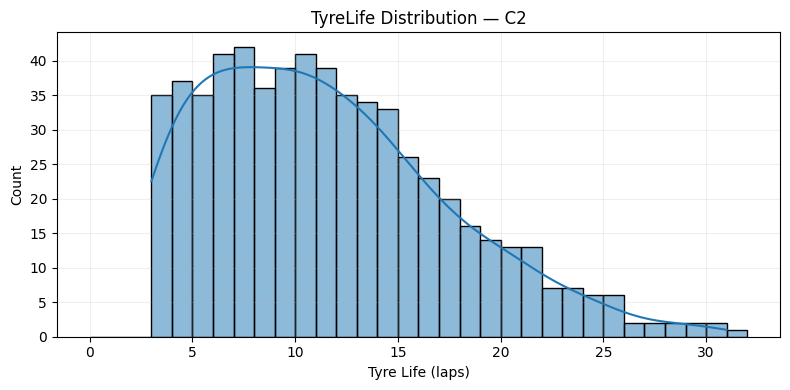

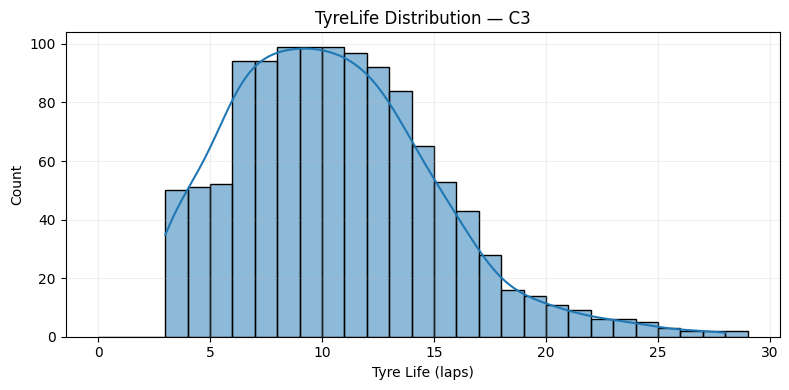

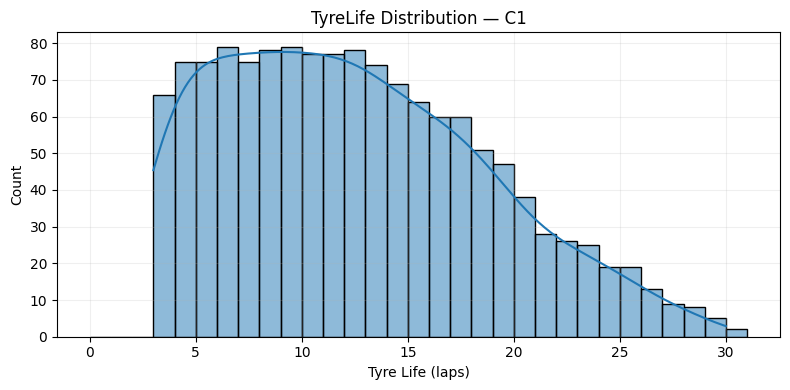

In [10]:
compounds_to_plot = ['C2', 'C3', 'C1']

for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['pirelliCompound'] == comp]
    elif 'Compound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['Compound'] == comp]
    else:
        subset = laps_cleaned[laps_cleaned.get('compound') == comp] if 'compound' in laps_cleaned.columns else laps_cleaned[[]]

    if subset.empty:
        print(f'No data available for compound {comp}. Skipping.')
        continue

    tyre_life = subset['TyreLife'].dropna()

    if tyre_life.empty:
        print(f'No valid TyreLife for {comp}. Skipping.')
        continue

    max_life = int(tyre_life.max()) if pd.api.types.is_numeric_dtype(tyre_life) else tyre_life.max()
    bins = range(0, max(2, max_life + 2)) if isinstance(max_life, int) else 10

    plt.figure(figsize=(8, 4))
    sns.histplot(tyre_life, bins=bins, kde=True, color='C0', stat='count')
    plt.title(f'TyreLife Distribution — {comp}')
    plt.xlabel('Tyre Life (laps)')
    plt.ylabel('Count')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Cumulative Distribution Function (CDF)

To complement histograms, we use the empirical CDF:

$$F(x) = P(X \leq x) = \frac{\#\{X_i \leq x\}}{n}$$

CDFs provide a bin-free view of the cumulative probability distribution and make it easier to compare variables with long-tailed behavior.

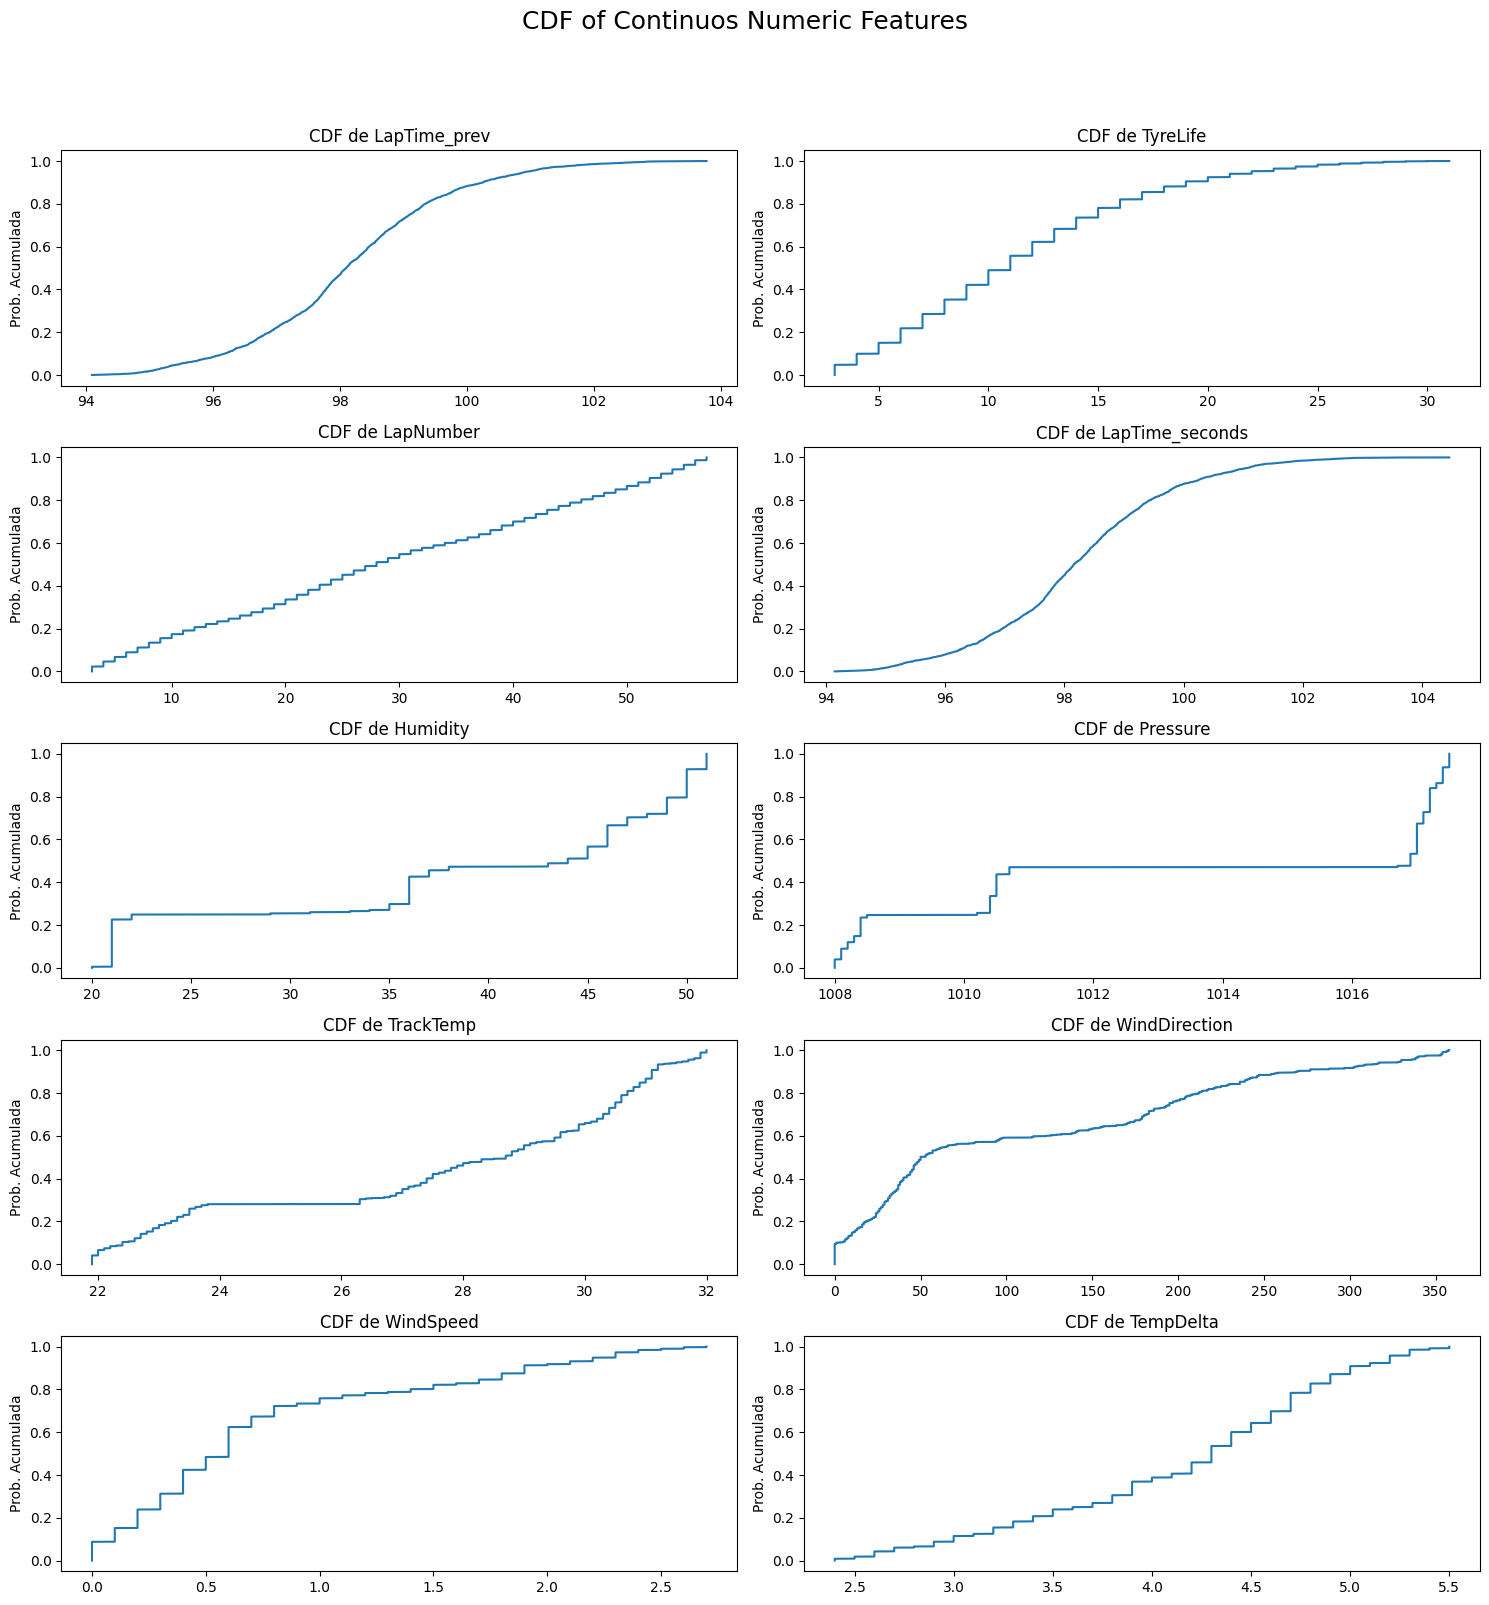

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig_cdf, axes_cdf = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cdf = axes_cdf.flatten()


for i, col in enumerate(continuous_cols):
    ax = flat_axes_cdf[i]

    data_to_plot = num_df[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'{col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:

        sorted_vals = np.sort(data_to_plot)
        cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

        ax.plot(sorted_vals, cdf_vals)
        ax.set_title(f'CDF de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Prob. Acumulada')

plt.suptitle('CDF of Continuos Numeric Features', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

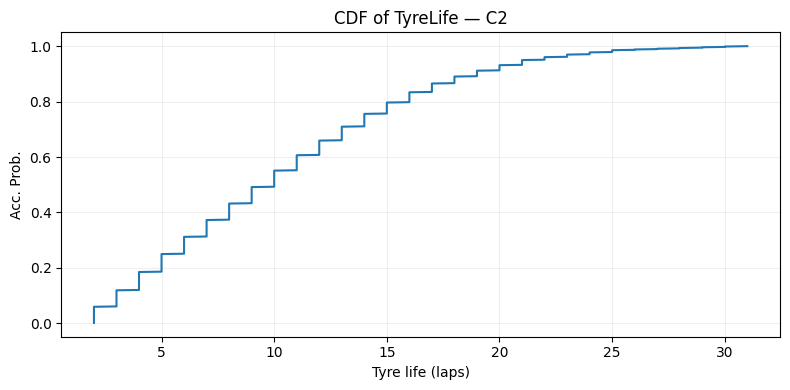

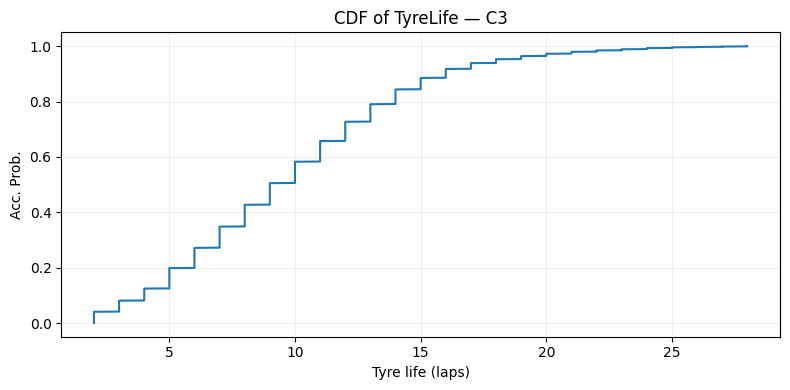

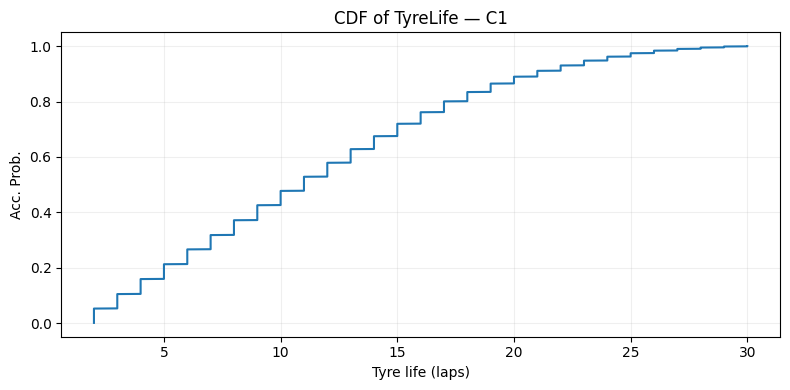

In [12]:
for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['pirelliCompound'] == comp]
    elif 'Compound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['Compound'] == comp]
    else:
        subset = laps_with_weather[laps_with_weather.get('compound') == comp] if 'compound' in laps_with_weather.columns else laps_with_weather[[]]

    if subset.empty:
        print(f'No data available for compound {comp}. Skipping.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'No valid TyreLife for {comp}. Skipping.')
        continue

    sorted_vals = np.sort(tyre_life)
    cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

    plt.figure(figsize=(8,4))
    plt.plot(sorted_vals, cdf_vals, color='C0')
    plt.title(f'CDF of TyreLife — {comp}')
    plt.xlabel('Tyre life (laps)')
    plt.ylabel('Acc. Prob.')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

---

## 7. Frequency Analysis: Categorical Variables

### Objective

Check class balance and representation across key categorical dimensions:

- `Driver`
- `Team`
- `pirelliCompound`
- `Year`

These distributions help explain potential model bias and the amount of information available for each group.

Generating frequency plots (Countplots) for categorical variables...


C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\3616753221.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\3616753221.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\3616753221.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\3616753221.py:27: UserWarning: set

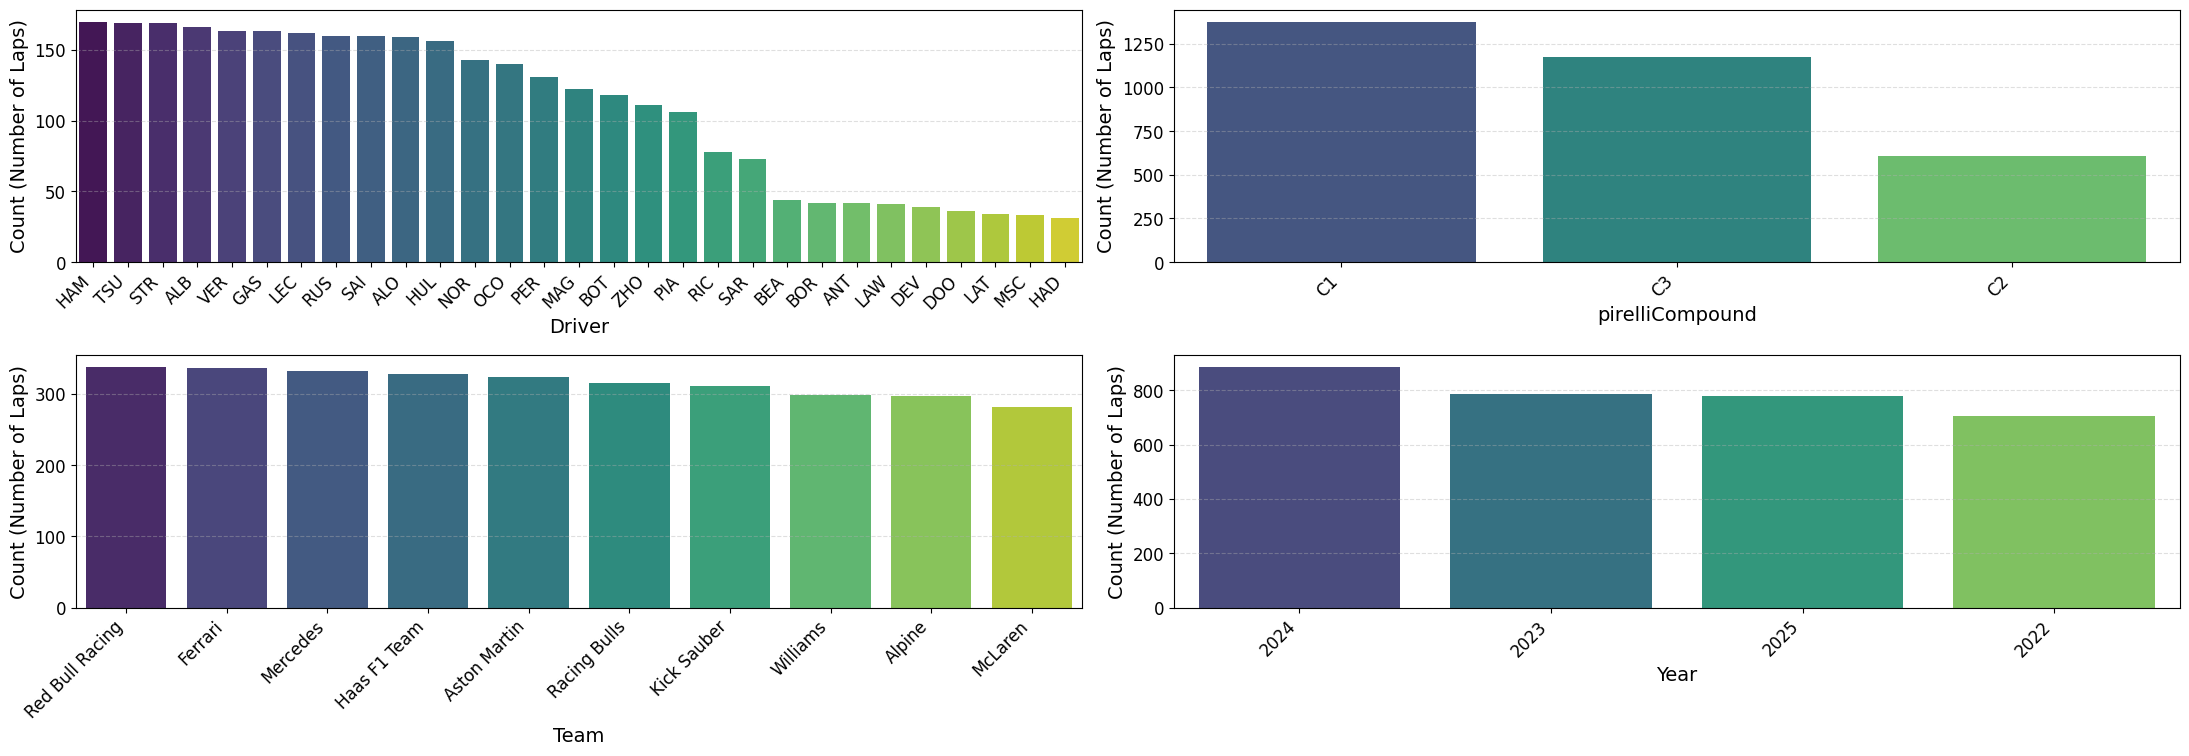

In [13]:
cat_cols = ['Driver', 'pirelliCompound', 'Team', 'Year']

print("Generating frequency plots (Countplots) for categorical variables...")


n_rows_cat = 2
n_cols_cat = 2
fig_cat, axes_cat = plt.subplots(n_rows_cat, n_cols_cat, figsize=(22, 8)) 

flat_axes_cat = axes_cat.flatten()

for i, col in enumerate(cat_cols):
    ax = flat_axes_cat[i]
    
    data_to_plot = laps_cleaned[col].dropna()
    
    if data_to_plot.empty:
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        bar_order = data_to_plot.value_counts().index
        
        sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")
        ax.set_xlabel(col, fontsize=14)
        ax.set_ylabel('Count (Number of Laps)', fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])

plt.show()

### Note on `TrackStatus`

`TrackStatus` encodes race-control states such as green flag, yellow flag, safety car, and red flag periods. Because this study already keeps only `IsAccurate=True` laps and focuses on regular race-pace modeling, `TrackStatus` is treated as an auxiliary diagnostic rather than a core predictor.

---

## 8. Dispersion and Outlier Diagnostics with Boxplots

Boxplots summarize the median, interquartile range (IQR), and extreme values of each numerical variable. They help verify whether the percentile-based filtering removed the most atypical observations while preserving the central race-pace distribution.

C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\4065725680.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\4065725680.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\4065725680.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_16636\4065725680.py:18: FutureWarni

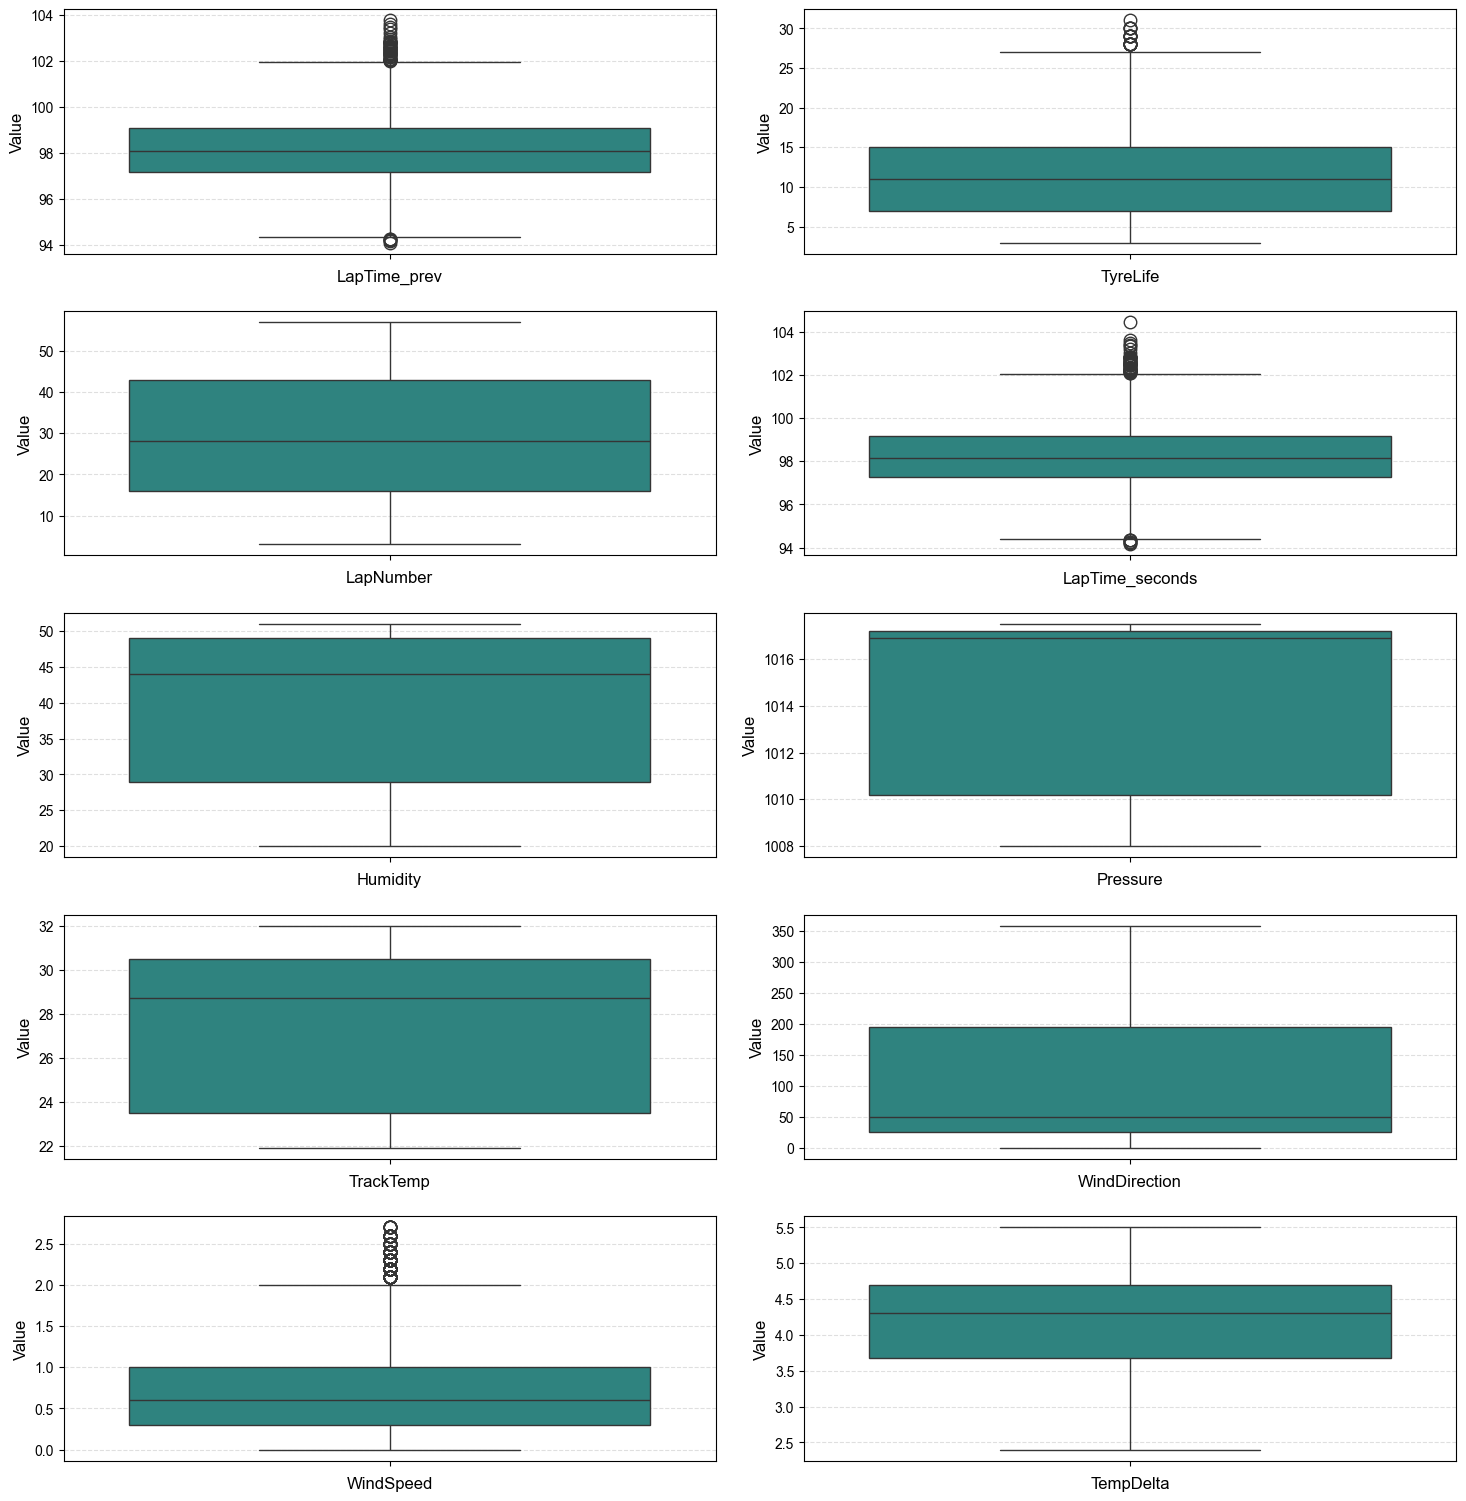

In [14]:
n_rows = 5
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 16))
flat_axes = axes.flatten()

sns.set_style("whitegrid")
sns.set_context("talk")

for i, col in enumerate(continuous_cols):
    ax = flat_axes[i]
    
    data_to_plot = laps_cleaned[col].dropna()
    
    if data_to_plot.empty:
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel('Value', fontsize=12)
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        ax.tick_params(axis='both', which='major', labelsize=10)
            
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

---

## 9. Descriptive Statistics and Distribution Moments

### Metrics

For the core numerical features, we report descriptive statistics and distribution moments, including skewness and kurtosis. These diagnostics support later transformation choices and help identify variables with asymmetric or heavy-tailed behavior.

In [15]:
try:
    stats_df = laps_cleaned.describe(include='all')

    features_interesse = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds',
    'Humidity', 'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
    ]

    skewness = laps_cleaned.skew(numeric_only=True)

    kurtosis = laps_cleaned.kurt(numeric_only=True)

    means = laps_cleaned.mean(numeric_only=True)
    stds = laps_cleaned.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)
    
    cv_series = pd.Series(cv, index=means.index)

    stats_df = stats_df[features_interesse]

    stats_df.loc['skewness'] = skewness
    stats_df.loc['kurtosis'] = kurtosis
    stats_df.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Statistics ---")
    display(stats_df)
    

except Exception as e:
    print(f"An error occurred while calculating the statistics: {e}")


--- Statistics ---


,LapTime_prev,TyreLife,LapNumber,LapTime_seconds,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed,TempDelta
count,3161.000000,3161.000000,3161.000000,3161.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,98.162712,11.382790,29.236950,98.234034,38.542405,1013.470918,27.598608,110.876266,0.761835,4.151551
std,1.575100,5.651280,16.189830,1.578209,11.324145,4.001441,3.348558,106.487395,0.690426,0.749653
min,94.090000,3.000000,3.000000,94.151000,20.000000,1008.000000,21.900000,0.000000,0.000000,2.400000
25%,97.170000,7.000000,16.000000,97.256000,29.000000,1010.200000,23.500000,26.000000,0.300000,3.675000
50%,98.094000,11.000000,28.000000,98.160000,44.000000,1016.900000,28.700000,50.000000,0.600000,4.300000
75%,99.099000,15.000000,43.000000,99.182000,49.000000,1017.200000,30.500000,195.000000,1.000000,4.700000


---

## 10. Skewness Diagnosis and Feature Transformation

### Why transform features?

Strong skewness can affect numerical stability and reduce model generalization. This section diagnoses asymmetric variables and applies transformations only when they are useful for the modeling pipeline.

In [16]:
skewed_features = {
    'right_skewed': [],
    'left_skewed': []
}

for feature in stats_df.columns:
    skewness_value = stats_df.at['skewness', feature]
    if pd.notna(skewness_value):
        if skewness_value > 1:
            skewed_features['right_skewed'].append(feature)
        elif skewness_value < -1:
            skewed_features['left_skewed'].append(feature)

print("\n--- Features with Notable Skewness ---")
print("Right Skewed (skewness > 1):", skewed_features['right_skewed'])
print("Left Skewed (skewness < -1):", skewed_features['left_skewed'])


--- Features with Notable Skewness ---
Right Skewed (skewness > 1): ['WindSpeed']
Left Skewed (skewness < -1): []


---

## 11. Strategic Analysis: Tyre Transition Matrix

### Objective

Estimate how often teams switch from one tyre compound to another between consecutive stints. This provides a compact view of race-strategy patterns and compound sequencing at the selected Grand Prix.

Analyzing transitions between compounds...

--- Stint Transition Count Matrix ---


To_Compound,C1,C2,C3
From_Compound,,,
C1,30,5,21
C2,16,9,19
C3,43,29,15



Generating transition matrix heatmap...


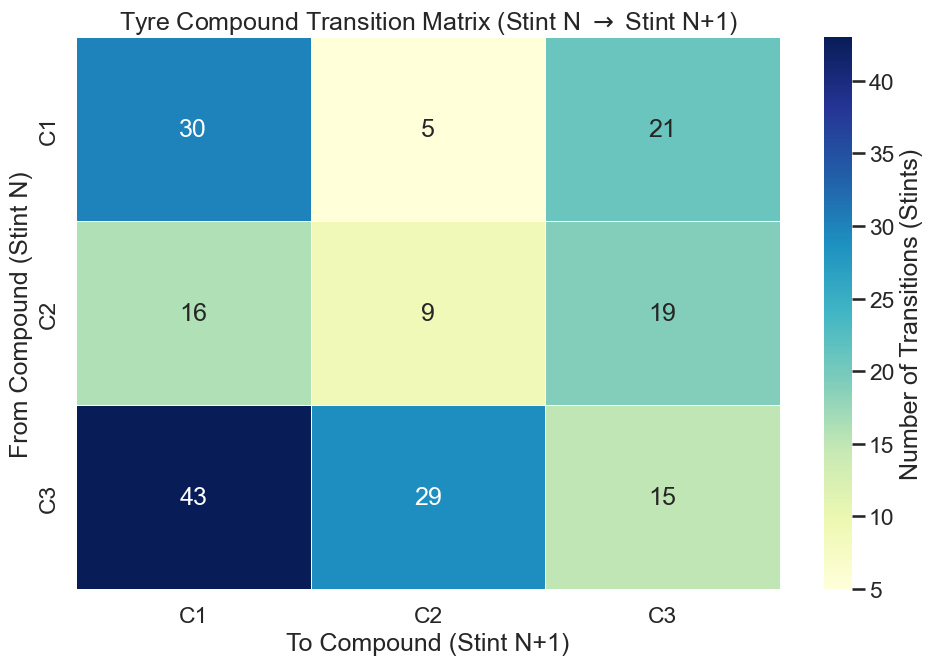

In [17]:
print("Analyzing transitions between compounds...")

try:
    stint_df = laps_cleaned[
        ['Year', 'Driver', 'Stint', 'pirelliCompound']
    ].drop_duplicates()
    
    stint_df = stint_df.sort_values(by=['Year', 'Driver', 'Stint'])
    stint_df['To_Compound'] = stint_df.groupby(['Year', 'Driver'])['pirelliCompound'].shift(-1)
    stint_df = stint_df.rename(columns={'pirelliCompound': 'From_Compound'})
    
    transitions_df = stint_df.dropna(subset=['To_Compound'])

    if transitions_df.empty:
        print("No transition data found (multiple stints) in the DataFrame.")
    else:
        transition_matrix = pd.crosstab(
            transitions_df['From_Compound'], 
            transitions_df['To_Compound']
        )

        print("\n--- Stint Transition Count Matrix ---")
        display(transition_matrix)

        print("\nGenerating transition matrix heatmap...")
        plt.figure(figsize=(10, 7))
        
        ax = sns.heatmap(
            transition_matrix, 
            annot=True, 
            fmt="d",  
            cmap="YlGnBu", 
            linewidths=.5,
            cbar_kws={'label': 'Number of Transitions (Stints)'}
        )
        
        ax.set_title('Tyre Compound Transition Matrix (Stint N $\\to$ Stint N+1)')
        ax.set_xlabel('To Compound (Stint N+1)')
        ax.set_ylabel('From Compound (Stint N)')
        plt.tight_layout()
        plt.show()

except NameErrorrrrrr:
    print("Errorrrrrr: DataFrame 'laps_with_weather_filtered' was not found.")
    print("Please run the previous cell that defines this DataFrame.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---

## 12. Non-Linear Weather Transformations with RBF

### Motivation

Weather-performance relationships in Formula 1 are rarely purely linear. Around an operating region, changes in track temperature, humidity, pressure, wind speed, wind direction, and thermal delta may affect lap time in non-linear ways.

This notebook applies RBF-style transformations centered on historical medians for multimodal weather variables.

Applying RBF Transformation (Gamma=0.1) using MEDIAN as reference...
Column 'TrackTemp': Median = 28.70
Column 'Humidity': Median = 44.00
Column 'Pressure': Median = 1016.90
Column 'WindSpeed': Median = 0.60
Column 'WindDirection': Median = 50.00
Column 'TempDelta': Median = 4.30


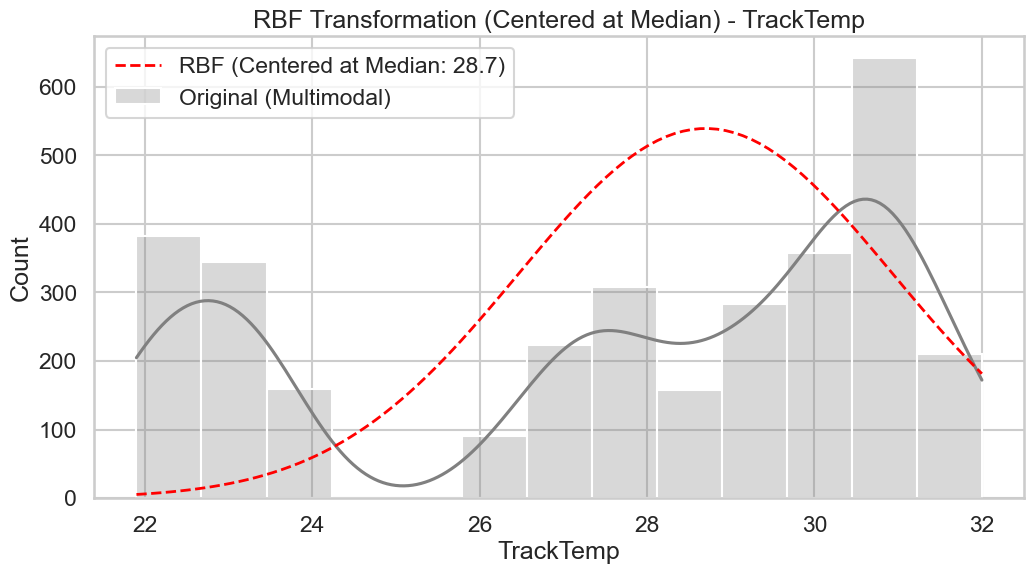


New Features Created: ['TrackTemp_RBF_Median', 'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median', 'WindDirection_RBF_Median', 'TempDelta_RBF_Median']


In [18]:
weather_cols = ['TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'TempDelta']
gamma_value = 0.1

print(f"Applying RBF Transformation (Gamma={gamma_value}) using MEDIAN as reference...")

for col in weather_cols:
    if col in laps_cleaned.columns:
        median_val = laps_cleaned[col].median()
        print(f"Column '{col}': Median = {median_val:.2f}")
        
        col_name = f"{col}_RBF_Median"
        squared_dist = (laps_cleaned[col] - median_val) ** 2
        laps_cleaned[col_name] = np.exp(-gamma_value * squared_dist)
        laps_cleaned[col_name] = laps_cleaned[col_name].fillna(0)

col_exemplo = 'TrackTemp'
if col_exemplo in weather_cols:
    col_transformed = f"{col_exemplo}_RBF_Median"
    median_exemplo = laps_cleaned[col_exemplo].median()
    
    plt.figure(figsize=(12, 6))
    ax1 = plt.gca()
    
    sns.histplot(laps_cleaned[col_exemplo], kde=True, ax=ax1, color='gray', alpha=0.3, label='Original (Multimodal)')
    
    x_range = np.linspace(laps_cleaned[col_exemplo].min(), laps_cleaned[col_exemplo].max(), 100)
    y_rbf = np.exp(-gamma_value * (x_range - median_exemplo)**2)
    
    y_max_hist = ax1.get_ylim()[1]
    plt.plot(x_range, y_rbf * y_max_hist * 0.8, color='red', linewidth=2, linestyle='--', label=f'RBF (Centered at Median: {median_exemplo:.1f})')
    plt.title(f'RBF Transformation (Centered at Median) - {col_exemplo}')
    plt.legend()
    plt.show()

new_features = [c for c in laps_cleaned.columns if '_RBF_Median' in c]
print(f"\nNew Features Created: {new_features}")

---

## 13. Multivariate Analysis: Pearson Correlation Matrix

### Objective

Quantify linear relationships among predictors and with `LapTime_seconds`, while inspecting potential multicollinearity.

The matrix uses Pearson correlation after combining numerical variables with one-hot encoded categorical variables.

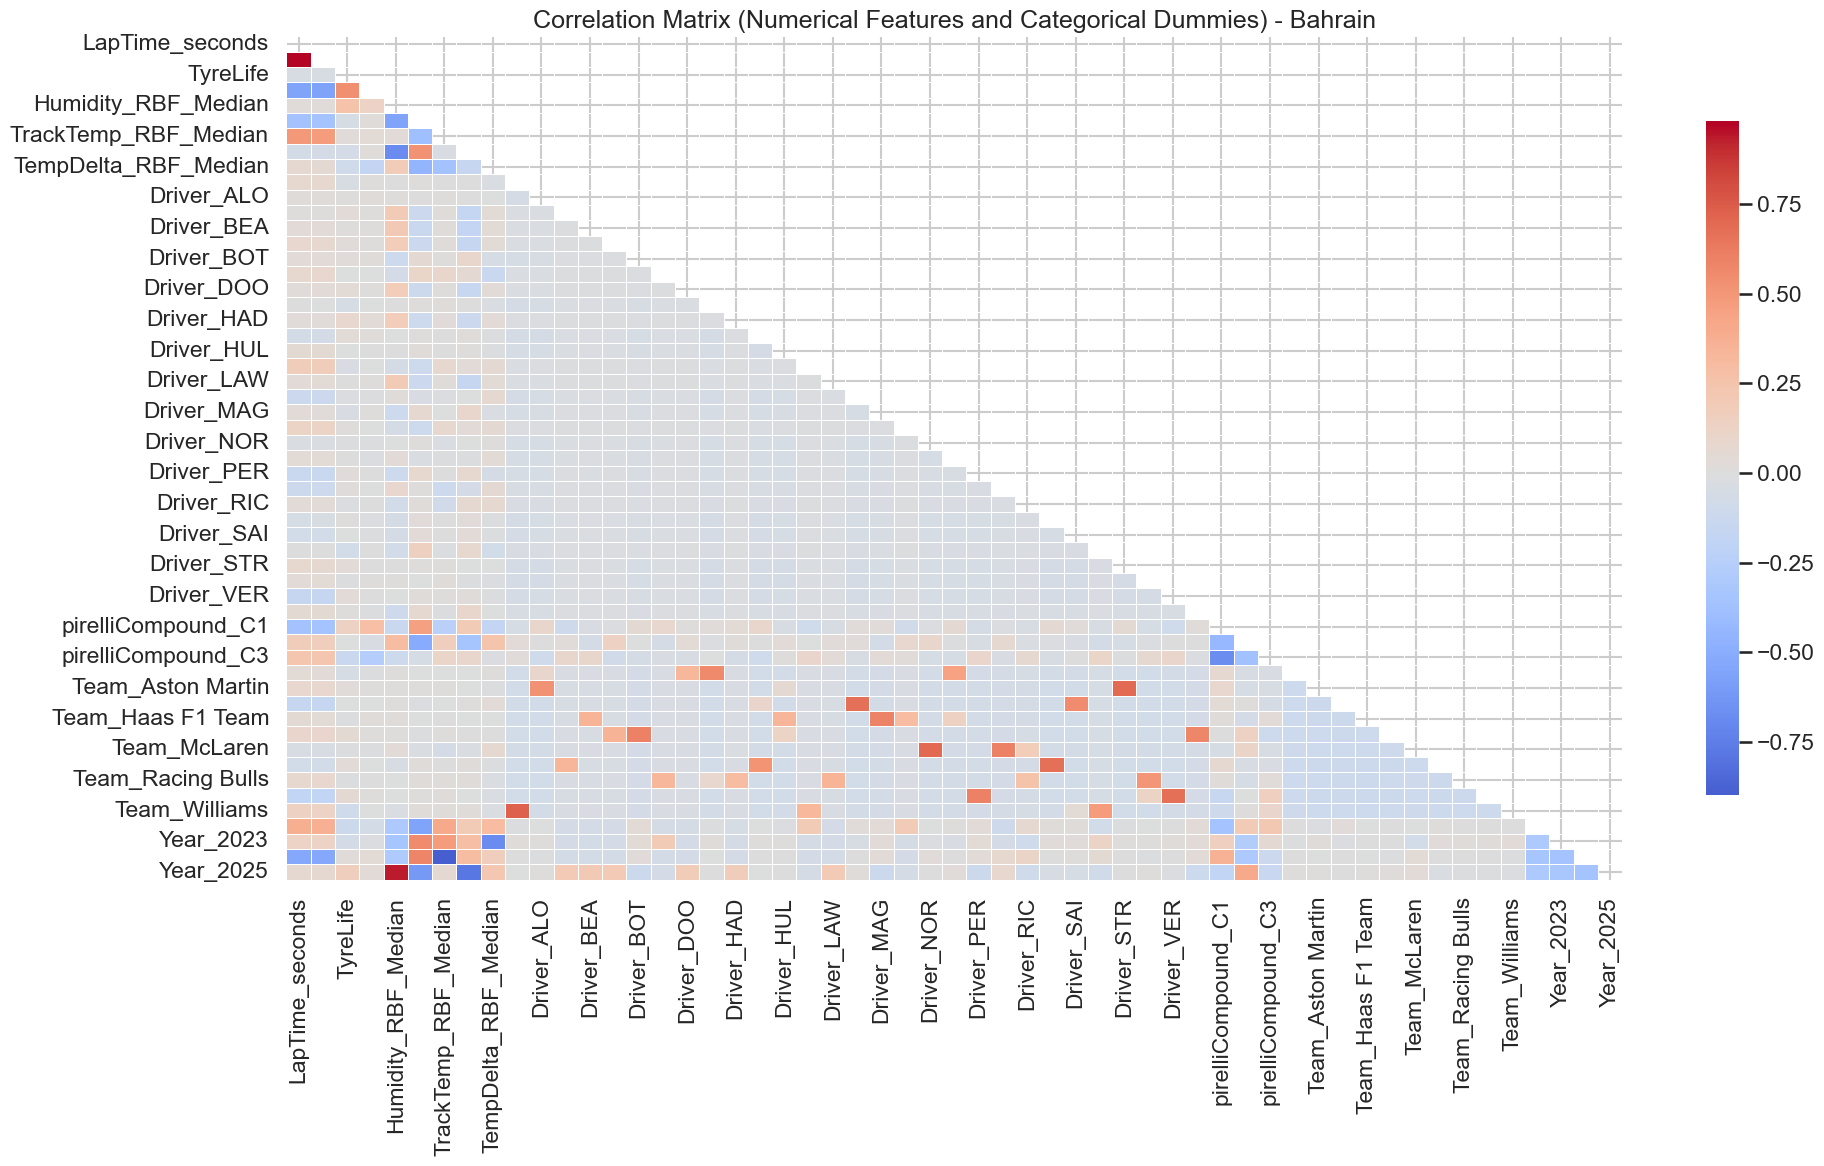

In [20]:
num_cols = ['LapTime_seconds', 'LapTime_prev', 'TyreLife', 'LapNumber',
            'Humidity_RBF_Median', 'Pressure_RBF_Median', 'TrackTemp_RBF_Median', 
            'WindSpeed_RBF_Median','TempDelta_RBF_Median']

cat_cols = ['Driver', 'pirelliCompound', 'Team', 'Year']

cat_dummies = pd.get_dummies(laps_cleaned[cat_cols].astype(str), prefix=cat_cols)
num_df = laps_cleaned[num_cols].copy()
corr_df_full = pd.concat([num_df, cat_dummies], axis=1)
corr_df_clean = corr_df_full.dropna()
corr_matrix = corr_df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 12))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    annot=False, 
    fmt=".2f", 
    cbar_kws={"shrink": .8}, 
    linewidths=.5
)
plt.title('Correlation Matrix (Numerical Features and Categorical Dummies) - Bahrain')
plt.tight_layout()
plt.show()

---

## 14. Dimensionality Reduction with PCA

### Why PCA?

With transformed numerical features and encoded categorical variables, PCA helps measure redundancy and summarize variance structure in a lower-dimensional space. The goal is diagnostic: to understand feature structure, not to replace the supervised models.

Starting data preparation for PCA
Dataset ready for ML. Shape: (3161, 55)

--- Running PCA ---
[8.73193626e-02 6.79376155e-02 4.65283822e-02 4.27288901e-02
 3.99865615e-02 3.90332539e-02 3.83276074e-02 3.76722400e-02
 3.70038271e-02 3.67463729e-02 3.58438116e-02 3.46819200e-02
 2.98642009e-02 2.35825318e-02 2.04855534e-02 1.93881404e-02
 1.91801331e-02 1.91390406e-02 1.90727352e-02 1.90392933e-02
 1.89656601e-02 1.88859022e-02 1.88612948e-02 1.87413859e-02
 1.87220574e-02 1.86292047e-02 1.85343487e-02 1.84937693e-02
 1.83175615e-02 1.78375799e-02 1.67546376e-02 1.53445249e-02
 1.46589933e-02 1.30335412e-02 1.05049740e-02 6.83098029e-03
 5.30660624e-03 4.47509470e-03 2.72996863e-03 2.47102004e-03
 2.34590996e-03 1.37422243e-03 1.02782714e-03 9.85838576e-04
 7.65147899e-04 7.15296229e-04 5.85545657e-04 3.04157943e-04
 2.33976151e-04 1.49905007e-06 1.71493796e-17 4.67057706e-18
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


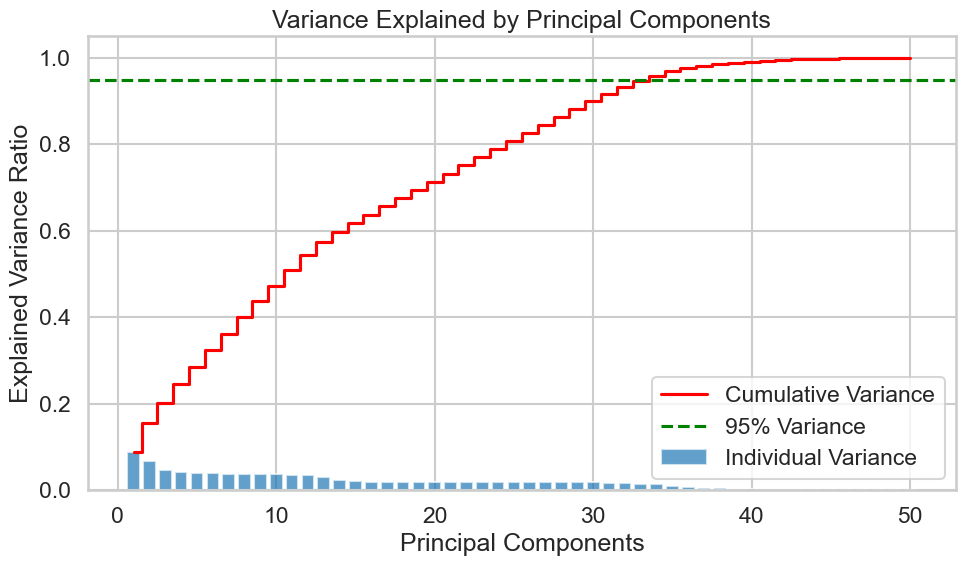

Number of Components for 95% Variance: 34


In [21]:
try:
    print("Starting data preparation for PCA")
    
    ml_df_full = pd.concat([num_df, cat_dummies], axis=1)
    imputer_num = SimpleImputer(strategy='mean')
    ml_df_imputed_num = imputer_num.fit_transform(ml_df_full[num_cols])
    num_df_imputed = pd.DataFrame(ml_df_imputed_num, columns=num_cols, index=ml_df_full.index)
    ml_df_imputed_analysis = pd.concat([num_df_imputed, cat_dummies], axis=1)
    
    scaler = StandardScaler()
    ml_df_scaled = scaler.fit_transform(ml_df_imputed_analysis)
    
    print(f"Dataset ready for ML. Shape: {ml_df_scaled.shape}")
    print("\n--- Running PCA ---")
    
    pca = PCA()
    pca.fit(ml_df_scaled)
    
    explained_variance_ratio = pca.explained_variance_ratio_
    print(explained_variance_ratio)
    
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    plt.figure(figsize=(10, 6))
    num_components_to_plot = min(50, len(cumulative_variance))
    plt.bar(range(1, num_components_to_plot + 1), explained_variance_ratio[:num_components_to_plot], 
            alpha=0.7, align='center', label='Individual Variance')
    plt.step(range(1, num_components_to_plot + 1), cumulative_variance[:num_components_to_plot], 
             where='mid', label='Cumulative Variance', color='red')
    plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
    plt.ylabel('Explained Variance Ratio')
    plt.xlabel('Principal Components')
    plt.title('Variance Explained by Principal Components')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    n_components_95_idx = np.where(cumulative_variance >= 0.95)[0]
    if n_components_95_idx.size > 0:
        n_components_95 = n_components_95_idx[0] + 1
    else:
        n_components_95 = len(cumulative_variance)
        
    print(f"Number of Components for 95% Variance: {n_components_95}")

except NameErrorrrrrr as e:
    print(f"ERRORRRR: DataFrame 'laps_with_weather' was not found ({e}).")
    print("Please run the cell that loads and processes the data for ONE race first (the one that creates 'laps_with_weather').")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [22]:
def plot_pca_loadings_subset_3d(pca, feature_list, full_feature_list, title):
    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]
    pc3 = loadings[:, 2]
    
    idx = [full_feature_list.get_loc(feat) for feat in feature_list]
    
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=pc1[idx],
        y=pc2[idx],
        z=pc3[idx],
        mode='markers+text',
        text=[full_feature_list[i] for i in idx],
        textposition="top center",
        marker=dict(
            size=6,
            line=dict(width=1, color='black')
        )
    ))
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3",
        ),
        width=800,
        height=700
    )
    fig.show()


feature_names = ml_df_imputed_analysis.columns

lap_tyres_features = [
    'LapTime_seconds', 'LapTime_prev', 'TyreLife', 'LapNumber',
    'pirelliCompound_C1', 'pirelliCompound_C2', 'pirelliCompound_C3'
]
plot_pca_loadings_subset_3d(
    pca,
    lap_tyres_features,
    feature_names,
    title="PCA Loadings — Lap Time and Tyre Variables"
)

weather_features = [
    'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median',
    'TrackTemp_RBF_Median', 'TempDelta_RBF_Median'
]
plot_pca_loadings_subset_3d(
    pca,
    weather_features,
    feature_names,
    title="PCA Loadings — Weather - Bahrain"
)

team_features = [col for col in feature_names if col.startswith('Team_')]
plot_pca_loadings_subset_3d(
    pca,
    team_features,
    feature_names,
    title="PCA Loadings — Teams - Bahrain"
)

driver_features = [col for col in feature_names if col.startswith('Driver_')]
plot_pca_loadings_subset_3d(
    pca,
    driver_features,
    feature_names,
    title="PCA Loadings — Drivers - Bahrain"
)

year_features = [col for col in feature_names if col.startswith('Year_')]
plot_pca_loadings_subset_3d(
    pca,
    year_features,
    feature_names,
    title="PCA Loadings — Years - Bahrain"
)

KeyError: 'WindDirection_RBF_Median'

In [ ]:
def plot_pca_loadings_subset_2d_static(pca, subset_features, full_feature_names, title):
    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]
    
    if not isinstance(full_feature_names, pd.Index):
        full_feature_names = pd.Index(full_feature_names)
    
    subset_features = [f for f in subset_features if f in full_feature_names]
    
    if len(subset_features) == 0:
        print(f"[WARNING] No features found: {title}")
        return
    
    idx = [full_feature_names.get_loc(f) for f in subset_features]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(pc1[idx], pc2[idx])
    
    for i, feat in zip(idx, subset_features):
        plt.text(pc1[i], pc2[i], feat, fontsize=12, ha='center', va='bottom')
    
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


feature_names = ml_df_imputed_analysis.columns

plot_pca_loadings_subset_2d_static(
    pca,
    [
        'LapTime_prev', 'TyreLife', 'LapNumber',
        'pirelliCompound_C1', 'pirelliCompound_C2', 'pirelliCompound_C3'
    ],
    feature_names,
    "PCA Loadings — Lap Time and Tyres - Bahrain"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [
        'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median',
        'TrackTemp_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median'
    ],
    feature_names,
    "PCA Loadings — Weather - Bahrain"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Team_")],
    feature_names,
    "PCA Loadings — Teams - Bahrain"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Driver_")],
    feature_names,
    "PCA Loadings — Drivers - Bahrain"
)

# Years
plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Year_")],
    feature_names,
    "PCA Loadings — Years - Bahrain"
)

---

## 15. Predictive Modeling I: Linear Regression Baseline

Before advanced models, we establish a transparent baseline with Linear Regression.

### Purpose

1. Provide a reference error level.
2. Evaluate how far a linear model can go with the engineered features.
3. Support interpretability through coefficients and statistical diagnostics.

In [ ]:
target_col = 'LapTime_seconds'

num_cols = [
    'TyreLife', 'LapNumber',
    'Humidity_RBF_Median', 'Pressure_RBF_Median', 'TrackTemp_RBF_Median',
    'WindSpeed_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median', 'LapTime_prev'
]
cat_cols = ['Driver', 'Team', 'pirelliCompound', 'Year']

print("Preparing data for Linear Regression (Baseline)...")

num_cols = [c for c in num_cols if c in laps_cleaned.columns]
cat_cols = [c for c in cat_cols if c in laps_cleaned.columns]

X_base = laps_cleaned[num_cols + cat_cols].copy()
y = laps_cleaned[target_col].copy()

valid_indices = y.dropna().index
X_base = X_base.loc[valid_indices]
y = y.loc[valid_indices]

X_encoded = pd.get_dummies(X_base, columns=cat_cols, drop_first=True)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns)
X_test = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns)

print(f"Final shape of X_train: {X_train.shape}")
print(f"Final shape of X_test: {X_test.shape}")

print("Training Linear Regression...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- BASELINE RESULTS (Linear Regression) ---")
print(f"RMSE (Root Mean Squared Errorrrrrr): {rmse_test:.4f} seconds")
print(f"MAE  (Mean Absolute Errorrrrrr):     {mae_test:.4f} seconds")
print(f"R²   (Coefficient of Determination): {r2_test:.4f}")

coefs = pd.DataFrame({'Feature': X_train.columns, 'Coef': model_lr.coef_})
coefs['Abs_Coef'] = coefs['Coef'].abs()

print("\nMost Impactful Variables:")
display(coefs.sort_values(by='Abs_Coef', ascending=False))

---

## 16. Baseline Diagnostics: Residual Analysis

### Why residual diagnostics?

Aggregate metrics such as RMSE, MAE, and R² can hide structural issues. Residual plots reveal model behavior related to homoscedasticity, normality, independence, and agreement between actual and predicted lap times.

In [ ]:
def plot_regression_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Regression Diagnostics: {model_name}', fontsize=16)
    
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Predicted Values')
    axes[0, 0].set_ylabel('Residuals (Errorrrrrr)')
    axes[0, 0].set_title('1. Residuals vs Predicted (Homoscedasticity)')
    
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('2. Normal QQ-Plot of Residuals')
    
    axes[1, 0].plot(residuals.values, marker='o', linestyle='none', alpha=0.5, markersize=3)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Instance Number (Index)')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].set_title('3. Residuals vs Instance (Independence)')
    
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[1, 1], alpha=0.5)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
    
    axes[1, 1].set_xlabel('Actual Value (Target)')
    axes[1, 1].set_ylabel('Predicted Value')
    axes[1, 1].set_title('4. Actual vs Predicted')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def calculate_confidence_intervals(y_true, y_pred, metric_func, metric_name, n_bootstraps=1000):
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    
    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred)
    
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue
        
        score = metric_func(y_true[indices], y_pred[indices])
        if metric_name == 'RMSE':
            score = np.sqrt(score)
        
        bootstrapped_scores.append(score)
    
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    
    confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    mean_score = np.mean(sorted_scores)
    
    return mean_score, confidence_lower, confidence_upper


print("Generating diagnostics for Linear Regression...")
plot_regression_diagnostics(y_test, y_pred_test, "Linear Regression (Baseline) Bahrain GP")

In [ ]:
print("Resetting indices for Statsmodels...")
X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

X_train_sm = sm.add_constant(X_train_reset)

print("Training OLS model...")
model_sm = sm.OLS(y_train_reset, X_train_sm).fit()
print(model_sm.summary())

r2_test_sm = r2_score(y_test, y_pred_test)
rmse_test_sm = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test_sm = mean_absolute_error(y_test, y_pred_test)

print("\n--- BASELINE RESULTS on Test Set (Statsmodels OLS) ---")
print(f"RMSE (Root Mean Squared Errorrrrrr):      {rmse_test_sm:.4f} seconds")
print(f"MAE  (Mean Absolute Errorrrrrr):          {mae_test_sm:.4f} seconds")
print(f"R²   (Coefficient of Determination): {r2_test_sm:.4f}")

---

## 17. Feature Selection and Model Parsimony

This stage evaluates feature relevance using statistical significance and uncertainty-aware diagnostics. The goal is to reduce unnecessary complexity without sacrificing predictive robustness.

### Iterative Evaluation Strategy

Candidate reductions are evaluated iteratively and decisions are tied to metrics and confidence intervals. The emphasis is robustness over single-run improvements.

In [ ]:
def calculate_metrics_and_ci(residuals, confidence=0.95):
    squared_errors = residuals ** 2
    mse = squared_errors.mean()
    rmse_val = np.sqrt(mse)
    
    mse_ci = stats.t.interval(confidence, len(squared_errors)-1,
                              loc=mse, scale=stats.sem(squared_errors))
    rmse_ci = (np.sqrt(max(0, mse_ci[0])), np.sqrt(mse_ci[1]))
    
    abs_errors = np.abs(residuals)
    mae_val = abs_errors.mean()
    mae_ci = stats.t.interval(confidence, len(abs_errors)-1,
                              loc=mae_val, scale=stats.sem(abs_errors))
    
    return rmse_val, rmse_ci, mae_val, mae_ci


print("Calculating Baseline (Full Model)...")
n_obs = len(y_train)
full_model = sm.OLS(y_train.values, X_train_sm).fit()
rmse_full, ci_rmse_full, mae_full, ci_mae_full = calculate_metrics_and_ci(full_model.resid)

print(f"BASELINE (Full):")
print(f"  RMSE: {rmse_full:.4f} | 95% CI: [{ci_rmse_full[0]:.4f}, {ci_rmse_full[1]:.4f}]")
print(f"  MAE:  {mae_full:.4f} | 95% CI: [{ci_mae_full[0]:.4f}, {ci_mae_full[1]:.4f}]")

features = list(X_train_sm.columns)
history = []

print("\nStarting Backward Elimination...")
header = f"{'Step':<5} | {'Removed Var.':<26} | {'P-val':<8} | {'RMSE (95% CI)':<28} | {'MAE (95% CI)':<28} | {'Sig?':<5}"
print("-" * len(header))
print(header)
print("-" * len(header))

step = 0
while len(features) > 0:
    X_curr = X_train_sm[features]
    model = sm.OLS(y_train.values, X_curr).fit()
    
    rmse_curr, ci_rmse_curr, mae_curr, ci_mae_curr = calculate_metrics_and_ci(model.resid)
    
    rss = model.ssr
    p = len(features)
    rmse_overlap = not (ci_rmse_curr[0] > ci_rmse_full[1])
    significant = "NO" if rmse_overlap else "YES!"
    
    p_values = model.pvalues
    max_p_value = p_values.max()
    worst_feature = p_values.idxmax()
    
    if max_p_value > 0.05:
        features.remove(worst_feature)
        
        rmse_str = f"{rmse_curr:.3f} [{ci_rmse_curr[0]:.3f}, {ci_rmse_curr[1]:.3f}]"
        mae_str = f"{mae_curr:.3f} [{ci_mae_curr[0]:.3f}, {ci_mae_curr[1]:.3f}]"
        
        history.append({
            'Step': step,
            'Removed': worst_feature,
            'RMSE': rmse_curr,
            'RMSE_Lower': ci_rmse_curr[0],
            'RMSE_Upper': ci_rmse_curr[1],
            'Significant_Change': significant
        })
        
        print(f"{step:<5} | {worst_feature:<26} | {max_p_value:.4f}   | {rmse_str:<28} | {mae_str:<28} | {significant:<5}")
        step += 1
    else:
        print("-" * len(header))
        print(f"Stopped! All p-values < 0.05.")
        print(f"Final Model: {len(features)} variables.")
        print(f"Final RMSE: {rmse_curr:.4f} [{ci_rmse_curr[0]:.4f}, {ci_rmse_curr[1]:.4f}]")
        break

print("\nFinal Variables:")
print(features)

final_model = sm.OLS(y_train.values, X_train_sm[features]).fit()
print(final_model.summary())

---

## 18. Baseline Under the Current Protocol: Sliding Window and Sequential Holdout

To compare fairly with XGBoost, the Linear Regression baseline follows the same temporal validation protocol used in the final experiment. The modeling set is evaluated with sliding windows and the final race segment is reserved as a sequential holdout.

In [ ]:
TARGET_COL = "LapTime_seconds"

NUM_COLS_BASE = [
    "TyreLife",
    "LapNumber",
    "Humidity_RBF_Median",
    "Pressure_RBF_Median",
    "TrackTemp_RBF_Median",
    "WindSpeed_RBF_Median",
    "TempDelta_RBF_Median",
    "LapTime_prev",
]

CAT_COLS = ["Driver", "Team", "pirelliCompound", "Year"]

HOLDOUT_RATIO    = 0.20
WINDOW_RATIO     = 0.20
WINDOW_TRAIN_RATIO = 0.80
WINDOW_STEP_RATIO  = 0.20
LAP_COL          = "LapNumber"


def calc_stats(values):
    mean_v = np.mean(values)
    if len(values) > 1:
        ci = stats.t.interval(0.95, len(values) - 1, loc=mean_v, scale=stats.sem(values))
    else:
        ci = (mean_v, mean_v)
    return mean_v, ci[0], ci[1]


def calc_holdout_ci(y_true, y_pred, n_bootstrap=1000, alpha=0.05, seed=42):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    if n < 2:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        return {"rmse": (rmse, rmse), "mae": (mae, mae), "r2": (r2, r2)}

    rng = np.random.default_rng(seed)
    rmse_samples, mae_samples, r2_samples = [], [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        yb  = y_true[idx]
        pb  = y_pred[idx]
        rmse_samples.append(np.sqrt(mean_squared_error(yb, pb)))
        mae_samples.append(mean_absolute_error(yb, pb))
        try:
            r2b = r2_score(yb, pb)
        except ValueErrorrrrrr:
            r2b = np.nan
        if np.isfinite(r2b):
            r2_samples.append(r2b)

    def percentile_ci(samples, point_value):
        if len(samples) == 0:
            return point_value, point_value
        lower = float(np.percentile(samples, 100 * (alpha / 2)))
        upper = float(np.percentile(samples, 100 * (1 - alpha / 2)))
        return lower, upper

    return {
        "rmse": percentile_ci(rmse_samples, np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae":  percentile_ci(mae_samples,  mean_absolute_error(y_true, y_pred)),
        "r2":   percentile_ci(r2_samples,   r2_score(y_true, y_pred)),
    }


def calc_cos_metric(error_sliding, error_final, std_sliding, std_final, alpha=0.5, beta=0.5):
    error_sliding = float(error_sliding)
    error_final = float(error_final)
    std_sliding = float(std_sliding)
    std_final = float(std_final)

    if np.isclose(error_final, 0) or np.isclose(std_final, 0):
        return np.nan, error_sliding, error_final, std_sliding, std_final

    cos = alpha * (error_sliding / error_final) + beta * (std_sliding / std_final)
    return cos, error_sliding, error_final, std_sliding, std_final

def build_sliding_windows(n_laps, window_ratio, train_ratio, step_ratio):
    if n_laps < 2:
        raise ValueErrorrrrrr("Insufficient data for sliding window (minimum 2 laps).")

    window_size = int(np.ceil(n_laps * window_ratio))
    window_size = max(2, min(window_size, n_laps))

    train_size = int(np.floor(window_size * train_ratio))
    train_size = max(1, train_size)
    if train_size >= window_size:
        train_size = window_size - 1

    val_size = window_size - train_size
    if val_size < 1:
        raise ValueErrorrrrrr("Invalid window: validation split is empty.")

    step_size = max(1, int(np.ceil(window_size * step_ratio)))

    windows = []
    start = 0
    while start + window_size <= n_laps:
        end = start + window_size
        windows.append((start, start + train_size, end))
        start += step_size

    last_start = n_laps - window_size
    if not windows or windows[-1][0] != last_start:
        windows.append((last_start, last_start + train_size, last_start + window_size))

    return windows, window_size, train_size, val_size, step_size


def build_sequential_split(df_base, valid_indices, holdout_ratio, lap_col):
    if lap_col not in df_base.columns:
        raise KeyErrorrrrrr(f"Column '{lap_col}' not found for sequential split.")

    lap_series = df_base.loc[valid_indices, lap_col]

    if lap_series.dropna().empty:
        raise ValueErrorrrrrr("No valid LapNumber values available for sequential split.")

    lap_min = int(np.floor(lap_series.min()))
    lap_max = int(np.floor(lap_series.max()))
    total_laps_track = lap_max - lap_min + 1

    if total_laps_track < 2:
        raise ValueErrorrrrrr("Insufficient number of laps to split train and holdout.")

    holdout_laps      = max(1, int(np.ceil(total_laps_track * holdout_ratio)))
    holdout_laps      = min(holdout_laps, total_laps_track - 1)
    holdout_start_lap = lap_max - holdout_laps + 1
    model_end_lap     = holdout_start_lap - 1

    model_mask   = (lap_series >= lap_min) & (lap_series <= model_end_lap)
    holdout_mask = (lap_series >= holdout_start_lap) & (lap_series <= lap_max)

    model_idx   = lap_series[model_mask].index
    holdout_idx = lap_series[holdout_mask].index

    if len(model_idx) == 0 or len(holdout_idx) == 0:
        raise ValueErrorrrrrr("Invalid sequential split: modeling or holdout is empty.")

    return (
        lap_series, lap_min, lap_max,
        model_idx, holdout_idx,
        holdout_start_lap, model_end_lap, total_laps_track, holdout_laps
    )


def align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first):
    X_train = X_train.copy()
    X_eval = X_eval.copy()

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("Missing").astype(str)
        X_eval[col] = X_eval[col].fillna("Missing").astype(str)

    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=drop_first)
    X_eval_enc = pd.get_dummies(X_eval, columns=cat_cols, drop_first=drop_first)
    X_eval_enc = X_eval_enc.reindex(columns=X_train_enc.columns, fill_value=0)
    return X_train_enc, X_eval_enc


def fit_predict_linear_regression(X_train, y_train, X_eval, cat_cols):
    X_train_enc, X_eval_enc = align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first=True)

    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()

    X_train_imp  = imputer.fit_transform(X_train_enc)
    X_eval_imp   = imputer.transform(X_eval_enc)
    X_train_sc   = scaler.fit_transform(X_train_imp)
    X_eval_sc    = scaler.transform(X_eval_imp)

    model = LinearRegression()
    model.fit(X_train_sc, y_train)
    return model.predict(X_eval_sc), model, imputer, scaler, X_train_enc.columns

df_base = laps_cleaned.copy()

num_cols_base = [c for c in NUM_COLS_BASE if c in df_base.columns]
cat_cols      = [c for c in CAT_COLS      if c in df_base.columns]

X_raw = df_base[num_cols_base + cat_cols].copy()
y_raw = df_base[TARGET_COL].copy()

valid_indices = y_raw.dropna().index
X_raw = X_raw.loc[valid_indices]
y_raw = y_raw.loc[valid_indices]

print("--- PREPARATION FOR LINEAR REGRESSION ---")
print(f"Numerical features : {num_cols_base}")
print(f"Categorical features: {cat_cols}")

X_lr = X_raw.copy()
y_lr = y_raw.copy()

(
    lap_series_lr, lap_min_lr, lap_max_lr,
    model_idx_lr, holdout_idx_lr,
    holdout_start_lap_lr, model_end_lap_lr,
    total_laps_lr, holdout_laps_lr
) = build_sequential_split(df_base, valid_indices, HOLDOUT_RATIO, LAP_COL)

X_model_lr   = X_lr.loc[model_idx_lr].copy()
y_model_lr   = y_lr.loc[model_idx_lr].copy()
X_holdout_lr = X_lr.loc[holdout_idx_lr].copy()
y_holdout_lr = y_lr.loc[holdout_idx_lr].copy()

model_lap_series_lr  = lap_series_lr.loc[model_idx_lr]
model_order_idx_lr   = model_lap_series_lr.sort_values(kind="mergesort").index
X_model_lr           = X_model_lr.loc[model_order_idx_lr].reset_index(drop=True)
y_model_lr           = y_model_lr.loc[model_order_idx_lr].reset_index(drop=True)
lap_model_sorted_lr  = model_lap_series_lr.loc[model_order_idx_lr].reset_index(drop=True)
unique_laps_model_lr = np.sort(pd.to_numeric(lap_model_sorted_lr, errors="coerce").dropna().unique())

if len(unique_laps_model_lr) < 2:
    raise ValueErrorrrrrr("Insufficient unique laps in modeling block for sliding window.")

print("\n--- SEQUENTIAL SPLIT DEFINED (LR) ---")
print(f"Total laps: {total_laps_lr} (LapNumber {lap_min_lr}–{lap_max_lr})")
print(f"Holdout (last 20%): laps {holdout_start_lap_lr}–{lap_max_lr} | Records: {len(X_holdout_lr)}")
print(f"Modeling (first 80%): laps {lap_min_lr}–{model_end_lap_lr} | Records: {len(X_model_lr)}")

sliding_windows_lr, window_size_lr, train_size_lr, val_size_lr, step_size_lr = build_sliding_windows(
    n_laps=len(unique_laps_model_lr),
    window_ratio=WINDOW_RATIO,
    train_ratio=WINDOW_TRAIN_RATIO,
    step_ratio=WINDOW_STEP_RATIO,
)

print("\n--- SLIDING WINDOW CONFIGURED (LR) ---")
print(
    f"window_ratio={WINDOW_RATIO:.2f} | window_size={window_size_lr} | "
    f"train/val={train_size_lr}/{val_size_lr} | step={step_size_lr} | "
    f"windows={len(sliding_windows_lr)}"
)

print("\n--- INTERNAL EVALUATION WITH SLIDING WINDOW (LR — within 80%) ---")
results_lr = {"window": [], "rmse": [], "mae": [], "r2": [], "std": []}
sw_coefs_lr = []

for i, (start, split, end) in enumerate(sliding_windows_lr, start=1):
    train_laps = unique_laps_model_lr[start:split]
    val_laps   = unique_laps_model_lr[split:end]
    train_mask = lap_model_sorted_lr.isin(train_laps)
    val_mask   = lap_model_sorted_lr.isin(val_laps)

    X_tr = X_model_lr.loc[train_mask]
    y_tr = y_model_lr.loc[train_mask]
    X_va = X_model_lr.loc[val_mask]
    y_va = y_model_lr.loc[val_mask]

    if len(X_tr) == 0 or len(X_va) == 0:
        raise ValueErrorrrrrr(f"Window {i}: empty train or validation fold.")

    preds, model_sw, _, _, feature_names_sw = fit_predict_linear_regression(X_tr, y_tr, X_va, cat_cols)
    sw_coefs_lr.append(pd.Series(model_sw.coef_, index=feature_names_sw))

    rmse_val = np.sqrt(mean_squared_error(y_va, preds))
    mae_val  = mean_absolute_error(y_va, preds)
    r2_val   = r2_score(y_va, preds)
    std_val  = np.std(np.asarray(y_va) - np.asarray(preds), ddof=1) if len(y_va) > 1 else 0.0

    results_lr["window"].append(i)
    results_lr["rmse"].append(rmse_val)
    results_lr["mae"].append(mae_val)
    results_lr["r2"].append(r2_val)
    results_lr["std"].append(std_val)

    print(
        f"Window {i} | train laps {int(train_laps[0])}–{int(train_laps[-1])} (n={len(X_tr)}) | "
        f"val laps {int(val_laps[0])}–{int(val_laps[-1])} (n={len(X_va)}) | "
        f"RMSE={rmse_val:.4f} | R²={r2_val:.4f}"
    )

print("\n--- COEFFICIENTS ACROSS SLIDING WINDOWS (LR) ---")
df_sw_coefs_lr  = pd.DataFrame(sw_coefs_lr)
mean_coefs_lr   = df_sw_coefs_lr.mean().abs().sort_values(ascending=False)
df_sw_coefs_lr  = df_sw_coefs_lr[mean_coefs_lr.index]
print("Mean and std of coefficients across windows (sorted by |mean|):")
display(df_sw_coefs_lr.agg(["mean", "std"]).T.sort_values(by="mean", key=abs, ascending=False))

print("\n--- TRAINING FINAL MODEL — 80% MODELING SET (LR) ---")
preds_holdout_lr, modelo_final_lr, imputer_final_lr, scaler_final_lr, feature_names_final_lr = fit_predict_linear_regression(
    X_model_lr, y_model_lr, X_holdout_lr, cat_cols
)

print("\n--- FINAL MODEL COEFFICIENTS — 80% MODELING SET (LR) ---")
final_coefs_lr = pd.Series(modelo_final_lr.coef_, index=feature_names_final_lr)
display(final_coefs_lr.reindex(final_coefs_lr.abs().sort_values(ascending=False).index).to_frame(name="Coefficient"))


holdout_ci_lr = calc_holdout_ci(y_holdout_lr.to_numpy(), preds_holdout_lr)
rmse_m_lr, rmse_l_lr, rmse_u_lr = calc_stats(results_lr["rmse"])
mae_m_lr,  mae_l_lr,  mae_u_lr  = calc_stats(results_lr["mae"])
r2_m_lr,   r2_l_lr,   r2_u_lr   = calc_stats(results_lr["r2"])
std_m_lr, std_l_lr, std_u_lr = calc_stats(results_lr["std"])
rmse_holdout_lr = np.sqrt(mean_squared_error(y_holdout_lr, preds_holdout_lr))
mae_holdout_lr = mean_absolute_error(y_holdout_lr, preds_holdout_lr)
std_holdout_lr = np.std(np.asarray(y_holdout_lr) - np.asarray(preds_holdout_lr), ddof=1) if len(y_holdout_lr) > 1 else 0.0
cos_mae_lr, mae_sw_cos_lr, mae_final_cos_lr, std_sw_cos_lr, std_final_cos_lr = calc_cos_metric(
    error_sliding=mae_m_lr,
    error_final=mae_holdout_lr,
    std_sliding=std_m_lr,
    std_final=std_holdout_lr,
    alpha=0.5,
    beta=0.5,
)
cos_rmse_lr, rmse_sw_cos_lr, rmse_final_cos_lr, _, _ = calc_cos_metric(
    error_sliding=rmse_m_lr,
    error_final=rmse_holdout_lr,
    std_sliding=std_m_lr,
    std_final=std_holdout_lr,
    alpha=0.5,
    beta=0.5,
)

cos_mae_windows_lr = (
    0.5 * (np.array(results_lr["mae"]) / mae_holdout_lr)
    + 0.5 * (np.array(results_lr["std"]) / std_holdout_lr)
)
cos_rmse_windows_lr = (
    0.5 * (np.array(results_lr["rmse"]) / rmse_holdout_lr)
    + 0.5 * (np.array(results_lr["std"]) / std_holdout_lr)
)
cos_mae_m_lr, cos_mae_l_lr, cos_mae_u_lr = calc_stats(cos_mae_windows_lr)
cos_rmse_m_lr, cos_rmse_l_lr, cos_rmse_u_lr = calc_stats(cos_rmse_windows_lr)


print("\n--- SLIDING WINDOW SUMMARY (LR — indicative CI) ---")
print("  NOTE: overlapping windows → CIs are indicative, not confirmatory.")
print(f"RMSE: {rmse_m_lr:.4f} | 95% CI: [{rmse_l_lr:.4f}, {rmse_u_lr:.4f}]")
print(f"MAE:  {mae_m_lr:.4f}  | 95% CI: [{mae_l_lr:.4f},  {mae_u_lr:.4f}]")
print(f"R²:   {r2_m_lr:.4f}   | 95% CI: [{r2_l_lr:.4f},   {r2_u_lr:.4f}]")

print(f"\n--- FINAL TEST — SEQUENTIAL HOLDOUT 20% (LR) ---")
print(f"Holdout: laps {holdout_start_lap_lr}–{lap_max_lr} | Records: {len(X_holdout_lr)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_holdout_lr, preds_holdout_lr)):.4f} | 95% CI: [{holdout_ci_lr['rmse'][0]:.4f}, {holdout_ci_lr['rmse'][1]:.4f}]")
print(f"MAE:  {mean_absolute_error(y_holdout_lr, preds_holdout_lr):.4f}  | 95% CI: [{holdout_ci_lr['mae'][0]:.4f},  {holdout_ci_lr['mae'][1]:.4f}]")
print(f"R²:   {r2_score(y_holdout_lr, preds_holdout_lr):.4f}   | 95% CI: [{holdout_ci_lr['r2'][0]:.4f},   {holdout_ci_lr['r2'][1]:.4f}]")
print(f"COS_MAE:  {cos_mae_lr:.4f} | 95% CI: [{cos_mae_l_lr:.4f}, {cos_mae_u_lr:.4f}]")
print(f"          MAE SW/final={mae_sw_cos_lr:.4f}/{mae_final_cos_lr:.4f} | STD SW/final={std_sw_cos_lr:.4f}/{std_final_cos_lr:.4f}")
print(f"COS_RMSE: {cos_rmse_lr:.4f} | 95% CI: [{cos_rmse_l_lr:.4f}, {cos_rmse_u_lr:.4f}]")
print(f"          RMSE SW/final={rmse_sw_cos_lr:.4f}/{rmse_final_cos_lr:.4f} | STD SW/final={std_sw_cos_lr:.4f}/{std_final_cos_lr:.4f}")


---

## 19. Predictive Modeling II: XGBoost and Optuna

### Why go beyond Linear Regression?

Lap-time dynamics include interactions and non-linear effects that a linear model may underfit. XGBoost is used as a non-linear tree-based model, with Optuna tuning the hyperparameters on the temporal validation protocol.

In [ ]:
print("--- PREPARATION FOR XGBOOST ---")
print(f"Numerical features : {num_cols_base}")
print(f"Categorical features: {cat_cols}")

X_raw_xgb = df_base[num_cols_base + cat_cols].copy()
y_raw_xgb = df_base[TARGET_COL].copy()

valid_indices_xgb = y_raw_xgb.dropna().index
X_raw_xgb = X_raw_xgb.loc[valid_indices_xgb]
y_raw_xgb = y_raw_xgb.loc[valid_indices_xgb]

X_xgb = X_raw_xgb.copy()
y_xgb = y_raw_xgb.copy()


if "align_one_hot_for_split" not in globals():
    def align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first):
        X_train = X_train.copy()
        X_eval = X_eval.copy()

        for col in cat_cols:
            X_train[col] = X_train[col].fillna("Missing").astype(str)
            X_eval[col] = X_eval[col].fillna("Missing").astype(str)

        X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=drop_first)
        X_eval_enc = pd.get_dummies(X_eval, columns=cat_cols, drop_first=drop_first)
        X_eval_enc = X_eval_enc.reindex(columns=X_train_enc.columns, fill_value=0)
        return X_train_enc, X_eval_enc


def build_xgb_matrix_for_split(X_train, X_eval, y_train, y_eval, cat_cols):
    X_train_enc, X_eval_enc = align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first=False)
    medians = X_train_enc.median(numeric_only=True)
    X_train_enc = X_train_enc.fillna(medians)
    X_eval_enc = X_eval_enc.fillna(medians)
    dtrain = xgb.DMatrix(X_train_enc, label=y_train)
    deval = xgb.DMatrix(X_eval_enc, label=y_eval)
    return dtrain, deval, X_train_enc, X_eval_enc

(
    lap_series_xgb, lap_min_xgb, lap_max_xgb,
    model_idx_xgb, holdout_idx_xgb,
    holdout_start_lap_xgb, model_end_lap_xgb,
    total_laps_xgb, holdout_laps_xgb
) = build_sequential_split(df_base, valid_indices_xgb, HOLDOUT_RATIO, LAP_COL)

X_model_xgb   = X_xgb.loc[model_idx_xgb].copy()
y_model_xgb   = y_xgb.loc[model_idx_xgb].copy()
X_holdout_xgb = X_xgb.loc[holdout_idx_xgb].copy()
y_holdout_xgb = y_xgb.loc[holdout_idx_xgb].copy()

model_lap_series_xgb  = lap_series_xgb.loc[model_idx_xgb]
model_order_idx_xgb   = model_lap_series_xgb.sort_values(kind="mergesort").index
X_model_xgb           = X_model_xgb.loc[model_order_idx_xgb].reset_index(drop=True)
y_model_xgb           = y_model_xgb.loc[model_order_idx_xgb].reset_index(drop=True)
lap_model_sorted_xgb  = model_lap_series_xgb.loc[model_order_idx_xgb].reset_index(drop=True)
unique_laps_model_xgb = np.sort(pd.to_numeric(lap_model_sorted_xgb, errors="coerce").dropna().unique())

if len(unique_laps_model_xgb) < 2:
    raise ValueErrorrrrrr("Insufficient unique laps in modeling block for sliding window.")

print("\n--- SEQUENTIAL SPLIT DEFINED (XGBoost) ---")
print(f"Total laps: {total_laps_xgb} (LapNumber {lap_min_xgb}–{lap_max_xgb})")
print(f"Holdout (last 20%): laps {holdout_start_lap_xgb}–{lap_max_xgb} | Records: {len(X_holdout_xgb)}")
print(f"Modeling (first 80%): laps {lap_min_xgb}–{model_end_lap_xgb} | Records: {len(X_model_xgb)}")

sliding_windows_xgb, window_size_xgb, train_size_xgb, val_size_xgb, step_size_xgb = build_sliding_windows(
    n_laps=len(unique_laps_model_xgb),
    window_ratio=WINDOW_RATIO,
    train_ratio=WINDOW_TRAIN_RATIO,
    step_ratio=WINDOW_STEP_RATIO,
)

print("\n--- SLIDING WINDOW CONFIGURED (XGBoost) ---")
print(
    f"window_ratio={WINDOW_RATIO:.2f} | window_size={window_size_xgb} | "
    f"train/val={train_size_xgb}/{val_size_xgb} | step={step_size_xgb} | "
    f"windows={len(sliding_windows_xgb)}"
)

USE_SAVED_XGB_PARAMS = True
OPTUNA_TRIALS = 100
BASE_XGB_PARAMS = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
    "nthread": -1,
}

json_path = "bahrain_xgb_params_sw.json"

print("\n--- OPTUNA TUNING ---")
best_params_xgb = None
best_params_train_xgb = None
best_n_xgb = None
final_params_xgb = None

if USE_SAVED_XGB_PARAMS and os.path.exists(json_path):
    print(f"Using saved parameters from: {json_path}")
    with open(json_path, "r") as f:
        loaded_params = json.load(f)

    loaded_n = int(loaded_params.get("n_estimators", 0))
    if loaded_n < 1:
        raise ValueErrorrrrrr("Invalid saved parameter file: 'n_estimators' missing or <= 0.")

    best_n_xgb            = loaded_n
    best_params_train_xgb = {k: v for k, v in loaded_params.items() if k != "n_estimators"}
    best_params_train_xgb = {**BASE_XGB_PARAMS, **best_params_train_xgb}
    best_params_xgb       = {k: v for k, v in best_params_train_xgb.items() if k not in BASE_XGB_PARAMS}
    final_params_xgb      = {**best_params_train_xgb, "n_estimators": best_n_xgb}

else:
    def objective(trial):
        param = {
            **BASE_XGB_PARAMS,
            "learning_rate":    trial.suggest_float("learning_rate",    0.01,  0.2,  log=True),
            "max_depth":        trial.suggest_int(  "max_depth",        3,     10),
            "min_child_weight": trial.suggest_int(  "min_child_weight", 1,     15),
            "subsample":        trial.suggest_float("subsample",        0.6,   1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6,   1.0),
            "gamma":            trial.suggest_float("gamma",            0.0,   5.0),
            "reg_alpha":        trial.suggest_float("reg_alpha",        1e-8, 10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda",       1e-8, 10.0, log=True),
        }

        rmse_scores = []
        for start, split, end in sliding_windows_xgb:
            train_laps = unique_laps_model_xgb[start:split]
            val_laps   = unique_laps_model_xgb[split:end]
            train_mask = lap_model_sorted_xgb.isin(train_laps)
            val_mask   = lap_model_sorted_xgb.isin(val_laps)

            X_tr = X_model_xgb.loc[train_mask]
            y_tr = y_model_xgb.loc[train_mask]
            X_va = X_model_xgb.loc[val_mask]
            y_va = y_model_xgb.loc[val_mask]

            if len(X_tr) == 0 or len(X_va) == 0:
                raise optuna.exceptions.TrialPruned()

            dtr, dva, _, _ = build_xgb_matrix_for_split(X_tr, X_va, y_tr, y_va, cat_cols)

            bst = xgb.train(
                params=param,
                dtrain=dtr,
                num_boost_round=2000,
                evals=[(dva, "validation")],
                early_stopping_rounds=50,
                verbose_eval=False,
            )
            preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
            rmse_scores.append(np.sqrt(mean_squared_error(y_va, preds)))

        return float(np.mean(rmse_scores))

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

    best_params_xgb       = study.best_params
    best_params_train_xgb = {**BASE_XGB_PARAMS, **best_params_xgb}

    print("\n--- CALIBRATING N_ESTIMATORS VIA SLIDING WINDOW ---")
    best_iterations = []
    for start, split, end in sliding_windows_xgb:
        train_laps = unique_laps_model_xgb[start:split]
        val_laps   = unique_laps_model_xgb[split:end]
        train_mask = lap_model_sorted_xgb.isin(train_laps)
        val_mask   = lap_model_sorted_xgb.isin(val_laps)

        X_tr = X_model_xgb.loc[train_mask]
        y_tr = y_model_xgb.loc[train_mask]
        X_va = X_model_xgb.loc[val_mask]
        y_va = y_model_xgb.loc[val_mask]

        if len(X_tr) == 0 or len(X_va) == 0:
            raise ValueErrorrrrrr("Invalid sliding window split: empty train or validation fold.")

        dtr, dva, _, _ = build_xgb_matrix_for_split(X_tr, X_va, y_tr, y_va, cat_cols)

        bst = xgb.train(
            params=best_params_train_xgb,
            dtrain=dtr,
            num_boost_round=5000,
            evals=[(dva, "validation")],
            early_stopping_rounds=100,
            verbose_eval=False,
        )
        best_iterations.append(bst.best_iteration + 1)

    best_n_xgb       = max(1, int(np.median(best_iterations)))
    final_params_xgb = {**best_params_train_xgb, "n_estimators": best_n_xgb}

    with open(json_path, "w") as f:
        json.dump(final_params_xgb, f, indent=4)
    print(f"[SUCCESS] Optuna parameters saved at: {json_path}")

print("\n--- TRAINING FINAL MODEL — 80% MODELING SET (XGBoost) ---")
print(f"[FINAL MODEL] Fixed n_estimators={best_n_xgb} (determined via sliding window CV — no early stopping)")
dmodel_full_xgb, dholdout_xgb, X_model_xgb_encoded, X_holdout_xgb_encoded = build_xgb_matrix_for_split(
    X_model_xgb, X_holdout_xgb, y_model_xgb, y_holdout_xgb, cat_cols
)
modelo_final_xgb = xgb.train(
    params=best_params_train_xgb,
    dtrain=dmodel_full_xgb,
    num_boost_round=best_n_xgb,
    verbose_eval=False,
)
print(f"[SELECTED MODEL] XGBoost Regressor (Optuna) | n_estimators={best_n_xgb}")
print("\nFinal optimized parameters:")
print(final_params_xgb)

print("\n--- INTERNAL EVALUATION WITH SLIDING WINDOW (XGBoost — within 80%) ---")
results_xgb = {"window": [], "rmse": [], "mae": [], "r2": [], "std": []}

for i, (start, split, end) in enumerate(sliding_windows_xgb, start=1):
    train_laps = unique_laps_model_xgb[start:split]
    val_laps   = unique_laps_model_xgb[split:end]
    train_mask = lap_model_sorted_xgb.isin(train_laps)
    val_mask   = lap_model_sorted_xgb.isin(val_laps)

    X_tr = X_model_xgb.loc[train_mask]
    y_tr = y_model_xgb.loc[train_mask]
    X_va = X_model_xgb.loc[val_mask]
    y_va = y_model_xgb.loc[val_mask]

    if len(X_tr) == 0 or len(X_va) == 0:
        raise ValueErrorrrrrr(f"Window {i}: empty train or validation fold.")

    dtr, dva, _, _ = build_xgb_matrix_for_split(X_tr, X_va, y_tr, y_va, cat_cols)

    bst = xgb.train(
        params=best_params_train_xgb,
        dtrain=dtr,
        num_boost_round=best_n_xgb,
        evals=[(dva, "validation")],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    preds    = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
    rmse_val = np.sqrt(mean_squared_error(y_va, preds))
    mae_val  = mean_absolute_error(y_va, preds)
    r2_val   = r2_score(y_va, preds)
    std_val  = np.std(np.asarray(y_va) - np.asarray(preds), ddof=1) if len(y_va) > 1 else 0.0

    results_xgb["window"].append(i)
    results_xgb["rmse"].append(rmse_val)
    results_xgb["mae"].append(mae_val)
    results_xgb["r2"].append(r2_val)
    results_xgb["std"].append(std_val)

    print(
        f"Window {i} | train laps {int(train_laps[0])}–{int(train_laps[-1])} (n={len(X_tr)}) | "
        f"val laps {int(val_laps[0])}–{int(val_laps[-1])} (n={len(X_va)}) | "
        f"RMSE={rmse_val:.4f} | R²={r2_val:.4f}"
    )

rmse_m_xgb, rmse_l_xgb, rmse_u_xgb = calc_stats(results_xgb["rmse"])
mae_m_xgb,  mae_l_xgb,  mae_u_xgb  = calc_stats(results_xgb["mae"])
r2_m_xgb,   r2_l_xgb,   r2_u_xgb   = calc_stats(results_xgb["r2"])
std_m_xgb, std_l_xgb, std_u_xgb = calc_stats(results_xgb["std"])

print("\n--- SLIDING WINDOW SUMMARY (XGBoost — indicative CI) ---")
print("  NOTE: overlapping windows → CIs are indicative, not confirmatory.")
print(f"RMSE: {rmse_m_xgb:.4f} | 95% CI: [{rmse_l_xgb:.4f}, {rmse_u_xgb:.4f}]")
print(f"MAE:  {mae_m_xgb:.4f}  | 95% CI: [{mae_l_xgb:.4f},  {mae_u_xgb:.4f}]")
print(f"R²:   {r2_m_xgb:.4f}   | 95% CI: [{r2_l_xgb:.4f},   {r2_u_xgb:.4f}]")
print("  → Use holdout bootstrap CIs below for final comparison with Linear Regression.")

print(f"\n--- FINAL TEST — SEQUENTIAL HOLDOUT 20% (XGBoost) ---")
X_model_xgb = X_model_xgb_encoded
X_holdout_xgb = X_holdout_xgb_encoded
print(f"Holdout: laps {holdout_start_lap_xgb}–{lap_max_xgb} | Records: {len(X_holdout_xgb)}")

preds_model_xgb = modelo_final_xgb.predict(dmodel_full_xgb)
preds_holdout_xgb = modelo_final_xgb.predict(dholdout_xgb)

holdout_ci_xgb = calc_holdout_ci(y_holdout_xgb.to_numpy(), preds_holdout_xgb)
rmse_holdout_xgb = np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb))
mae_holdout_xgb = mean_absolute_error(y_holdout_xgb, preds_holdout_xgb)
std_holdout_xgb = np.std(np.asarray(y_holdout_xgb) - np.asarray(preds_holdout_xgb), ddof=1) if len(y_holdout_xgb) > 1 else 0.0
cos_mae_xgb, mae_sw_cos_xgb, mae_final_cos_xgb, std_sw_cos_xgb, std_final_cos_xgb = calc_cos_metric(
    error_sliding=mae_m_xgb,
    error_final=mae_holdout_xgb,
    std_sliding=std_m_xgb,
    std_final=std_holdout_xgb,
    alpha=0.5,
    beta=0.5,
)
cos_rmse_xgb, rmse_sw_cos_xgb, rmse_final_cos_xgb, _, _ = calc_cos_metric(
    error_sliding=rmse_m_xgb,
    error_final=rmse_holdout_xgb,
    std_sliding=std_m_xgb,
    std_final=std_holdout_xgb,
    alpha=0.5,
    beta=0.5,
)

cos_mae_windows_xgb = (
    0.5 * (np.array(results_xgb["mae"]) / mae_holdout_xgb)
    + 0.5 * (np.array(results_xgb["std"]) / std_holdout_xgb)
)
cos_rmse_windows_xgb = (
    0.5 * (np.array(results_xgb["rmse"]) / rmse_holdout_xgb)
    + 0.5 * (np.array(results_xgb["std"]) / std_holdout_xgb)
)
cos_mae_m_xgb, cos_mae_l_xgb, cos_mae_u_xgb = calc_stats(cos_mae_windows_xgb)
cos_rmse_m_xgb, cos_rmse_l_xgb, cos_rmse_u_xgb = calc_stats(cos_rmse_windows_xgb)


print(f"RMSE: {np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb)):.4f} | 95% CI: [{holdout_ci_xgb['rmse'][0]:.4f}, {holdout_ci_xgb['rmse'][1]:.4f}]")
print(f"MAE:  {mean_absolute_error(y_holdout_xgb, preds_holdout_xgb):.4f}  | 95% CI: [{holdout_ci_xgb['mae'][0]:.4f},  {holdout_ci_xgb['mae'][1]:.4f}]")
print(f"R²:   {r2_score(y_holdout_xgb, preds_holdout_xgb):.4f}   | 95% CI: [{holdout_ci_xgb['r2'][0]:.4f},   {holdout_ci_xgb['r2'][1]:.4f}]")
print(f"COS_MAE:  {cos_mae_xgb:.4f} | 95% CI: [{cos_mae_l_xgb:.4f}, {cos_mae_u_xgb:.4f}]")
print(f"          MAE SW/final={mae_sw_cos_xgb:.4f}/{mae_final_cos_xgb:.4f} | STD SW/final={std_sw_cos_xgb:.4f}/{std_final_cos_xgb:.4f}")
print(f"COS_RMSE: {cos_rmse_xgb:.4f} | 95% CI: [{cos_rmse_l_xgb:.4f}, {cos_rmse_u_xgb:.4f}]")
print(f"          RMSE SW/final={rmse_sw_cos_xgb:.4f}/{rmse_final_cos_xgb:.4f} | STD SW/final={std_sw_cos_xgb:.4f}/{std_final_cos_xgb:.4f}")


In [ ]:
print("\n--- FINAL MODEL PERFORMANCE ON SEQUENTIAL HOLDOUT (XGBoost) ---")
print(f"R²:   {r2_score(y_holdout_xgb, preds_holdout_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb)):.4f}")
print(f"MAE:  {mean_absolute_error(y_holdout_xgb, preds_holdout_xgb):.4f}")
print(f"COS_MAE:  {cos_mae_xgb:.4f} | 95% CI: [{cos_mae_l_xgb:.4f}, {cos_mae_u_xgb:.4f}]")
print(f"          MAE SW/final={mae_sw_cos_xgb:.4f}/{mae_final_cos_xgb:.4f} | STD SW/final={std_sw_cos_xgb:.4f}/{std_final_cos_xgb:.4f}")
print(f"COS_RMSE: {cos_rmse_xgb:.4f} | 95% CI: [{cos_rmse_l_xgb:.4f}, {cos_rmse_u_xgb:.4f}]")
print(f"          RMSE SW/final={rmse_sw_cos_xgb:.4f}/{rmse_final_cos_xgb:.4f} | STD SW/final={std_sw_cos_xgb:.4f}/{std_final_cos_xgb:.4f}")

importance_raw = modelo_final_xgb.get_score(importance_type="gain")

if len(importance_raw) > 0 and next(iter(importance_raw.keys())).startswith("f"):
    # DMatrix was built without feature_names — map f0, f1, ... back to column names
    colnames = list(X_model_xgb.columns)
    importance_named = {colnames[int(k[1:])]: v for k, v in importance_raw.items()}
else:
    importance_named = importance_raw

importance_df = (
    pd.DataFrame.from_dict(importance_named, orient="index", columns=["gain"])
      .sort_values("gain", ascending=False)
)

print("\n--- TOP 10 FEATURES BY GAIN (XGBoost Final Model) ---")
display(importance_df.head(10))

shap.initjs()
explainer   = shap.TreeExplainer(modelo_final_xgb)
shap_values = explainer.shap_values(X_model_xgb)

shap.summary_plot(shap_values, X_model_xgb, plot_size=(8, 6))

residuals_final = y_holdout_xgb.values - preds_holdout_xgb

plt.figure(figsize=(8, 4))
plt.hist(residuals_final, bins=50, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero error")
plt.title("Residual Distribution — Sequential Holdout (XGBoost)")
plt.xlabel("Residual (y_true − y_pred) [seconds]")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nResidual stats — Holdout:")
print(f"  Mean:   {residuals_final.mean():.4f} s")
print(f"  Std:    {residuals_final.std():.4f} s")
print(f"  |Max|:  {np.abs(residuals_final).max():.4f} s")

---

## 20. Final Visualization: 95% Confidence-Interval Comparison

Numerical tables are precise, but interval plots make statistical comparison easier to interpret. The final visualization compares Linear Regression and XGBoost using RMSE, MAE, and R² intervals on the sequential holdout protocol.

In [ ]:
rmse_data = {
    "Baseline (Linear)":  [rmse_m_lr,  rmse_l_lr,  rmse_u_lr],
    "XGBoost (Optimized)": [rmse_m_xgb, rmse_l_xgb, rmse_u_xgb],
}
mae_data = {
    "Baseline (Linear)":  [mae_m_lr,  mae_l_lr,  mae_u_lr],
    "XGBoost (Optimized)": [mae_m_xgb, mae_l_xgb, mae_u_xgb],
}

def plot_confidence_intervals(data, metric_name, ax):
    models = list(data.keys())
    means  = [data[m][0] for m in models]
    yerr   = np.array([
        [data[m][0] - data[m][1], data[m][2] - data[m][0]] for m in models
    ]).T

    colors = ["#95a5a6", "#2ecc71"]
    bars = ax.bar(
        models,
        means,
        yerr=yerr,
        capsize=10,
        color=colors,
        alpha=0.9,
        width=0.5,
        edgecolor="black",
        linewidth=1,
    )

    for i, bar in enumerate(bars):
        height      = bar.get_height()
        upper_limit = data[models[i]][2]
        label_pos   = upper_limit + (upper_limit * 0.01)
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            label_pos,
            f"{height:.4f}s",
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="black",
        )

    ax.set_title(f"{metric_name}", fontsize=22, pad=20, fontweight="bold")
    ax.set_ylabel(f"{metric_name} (seconds)", fontsize=18)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(0.15, 0.45)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_confidence_intervals(rmse_data, "RMSE", axes[0])
plot_confidence_intervals(mae_data,  "MAE",  axes[1])
plt.suptitle(
    "Robustness Comparison: Baseline vs XGBoost (95% CI) - Italy (2022-2025)",
    fontsize=20,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
if "df_base" not in dir():
    print("[INFO] df_base not found in namespace — recreating from laps_cleaned.")
    df_base = laps_cleaned.copy()
else:
    print("[INFO] df_base found in namespace.")

# Check the remaining critical dependencies
required_vars = [
    "holdout_idx_xgb", "y_holdout_xgb", "preds_holdout_xgb",
    "lap_series_xgb", "holdout_start_lap_xgb", "lap_max_xgb"
]
missing = [v for v in required_vars if v not in dir()]


def preprocess_like_training(df_raw, cat_cols, num_cols, train_columns):
    Xp = df_raw.copy()
    cat_cols_use = [c for c in cat_cols if c in Xp.columns]
    num_cols_use = [c for c in num_cols if c in Xp.columns]
    Xp[cat_cols_use] = Xp[cat_cols_use].fillna("Missing")
    Xp = pd.get_dummies(Xp, columns=cat_cols_use, drop_first=False)
    Xp[num_cols_use] = Xp[num_cols_use].apply(lambda s: s.fillna(s.median()), axis=0)
    Xp = Xp.reindex(columns=train_columns, fill_value=0)
    return Xp


def plot_driver_timeseries_with_ci_combined_mae(
    df_laps,
    y_true,
    y_pred,
    tyre_col="pirelliCompound",
    model_label="XGBoost (Final Model)",
    title_prefix="DRIVER - RACE",
    y_offset_min=0.5,
    compounds=("C3", "C2", "C1"),
    x_tick_step=5,
    y1_tick_step=3,
    y2_tick_step=0.2,
    ci_level=0.95,
    ci_method="mae",
    ci_alpha=0.18,
):
    df_plot = df_laps.copy().sort_values("LapNumber").copy()
    df_plot["Real"]      = np.array(y_true)
    df_plot["Predicted"] = np.array(y_pred)
    df_plot["Residual"]  = df_plot["Real"] - df_plot["Predicted"]

    mae  = np.mean(np.abs(df_plot["Residual"]))
    rmse = np.sqrt(np.mean(df_plot["Residual"] ** 2))

    if tyre_col in df_plot.columns:
        df_plot["Tyre_norm"] = df_plot[tyre_col].astype(str).str.upper().str.strip()
    else:
        df_plot["Tyre_norm"] = "UNK"

    ramp_colors = ["#e53935", "#fdd835", "#ffffff"]
    compounds   = tuple([str(c).upper().strip() for c in compounds])
    if len(compounds) != 3:
        raise ValueErrorrrrrr("The 'compounds' argument must contain exactly 3 values.")

    tyre_colors  = {compounds[i]: ramp_colors[i] for i in range(3)}
    point_colors = df_plot["Tyre_norm"].map(tyre_colors).fillna("#9e9e9e")

    xlim    = (47, 57)

    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z     = z_map.get(ci_level, 1.96)

    if ci_method == "rmse":
        sigma    = rmse
        ci_label = f"CI {int(ci_level*100)}% ~ Predicted +/- {z:.2f}*RMSE"
    elif ci_method == "mae":
        sigma    = mae
        ci_label = f"CI {int(ci_level*100)}% ~ Predicted +/- {z:.2f}*MAE"
    elif ci_method == "std":
        sigma    = np.std(df_plot["Residual"], ddof=1)
        ci_label = f"CI {int(ci_level*100)}% ~ Predicted +/- {z:.2f}*STD"
    else:
        raise ValueErrorrrrrr("ci_method must be 'rmse', 'mae' or 'std'.")

    ci_low  = df_plot["Predicted"] - z * sigma
    ci_high = df_plot["Predicted"] + z * sigma

    plt.close("all")
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        dpi=100,
    )

    fig.suptitle(title_prefix, fontsize=16, fontweight="bold", y=1.01)

    sns.lineplot(
        data=df_plot, x="LapNumber", y="Real",
        ax=ax1, label="Real Time",
        color="black", alpha=0.65, linewidth=2, errorbar=None,
    )
    sns.lineplot(
        data=df_plot, x="LapNumber", y="Predicted",
        ax=ax1, label=f"Predicted ({model_label})",
        color="red", linestyle="--", linewidth=2, errorbar=None,
    )

    ax1.fill_between(
        df_plot["LapNumber"].values,
        ci_low.values,
        ci_high.values,
        alpha=ci_alpha,
        label=ci_label,
    )

    ax1.scatter(
        df_plot["LapNumber"], df_plot["Real"],
        c=point_colors, s=60,
        edgecolors="black", linewidths=0.5,
        zorder=5, label="Tyre compound by lap",
    )

    ax1.set_ylabel("Lap Time (s)", fontsize=18)
    ax1.tick_params(axis="both", which="major", labelsize=15)
    ax1.grid(True, linestyle=":", alpha=0.6)

    y_min = min(df_plot["Real"].min(), df_plot["Predicted"].min(), ci_low.min()) - 5
    y_max = max(df_plot["Real"].max(), df_plot["Predicted"].max(), ci_high.max()) + 5
    ax1.set_ylim(y_min, y_max)

    tyres_present  = set(df_plot["Tyre_norm"].unique())
    ordered_tyres  = [t for t in compounds if t in tyres_present]
    extras         = sorted([t for t in tyres_present if t not in compounds])
    ordered_tyres += extras

    compound_handles = [
        Line2D(
            [0], [0],
            marker="o", linestyle="",
            markersize=10,
            markerfacecolor=tyre_colors.get(t, "#9e9e9e"),
            markeredgecolor="black",
            label=t,
        )
        for t in ordered_tyres
    ]

    leg_main = ax1.legend(loc="upper left", fontsize=14)
    leg_comp = ax1.legend(
        handles=compound_handles,
        title="Compounds",
        loc="upper right",
        frameon=True,
        fontsize=14,
        title_fontsize=14,
    )
    ax1.add_artist(leg_main)

    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax1.yaxis.set_major_locator(MultipleLocator(y1_tick_step))

    colors = np.where(df_plot["Residual"] >= 0, "red", "blue")
    ax2.bar(df_plot["LapNumber"], df_plot["Residual"], color=colors, alpha=0.75)
    ax2.axhline(0,     color="black", linewidth=1)
    ax2.axhline(+mae,  color="black", linestyle=":",  linewidth=1)
    ax2.axhline(-mae,  color="black", linestyle=":",  linewidth=1)
    ax2.axhline(+rmse, color="black", linestyle="--", linewidth=1)
    ax2.axhline(-rmse, color="black", linestyle="--", linewidth=1)

    ax2.text(
        0.99, 0.95,
        f"MAE={mae:.3f}s (dotted) | RMSE={rmse:.3f}s (dashed)\nResidual = Real - Predicted",
        transform=ax2.transAxes,
        fontsize=14, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

    ax2.set_title("Residuals (Real - Predicted)", fontsize=18, pad=10)
    ax2.set_ylabel("Errorrrrrr (s)", fontsize=18)
    ax2.set_xlabel("Lap Number", fontsize=18)
    ax2.tick_params(axis="both", which="major", labelsize=15)
    ax2.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax2.yaxis.set_major_locator(MultipleLocator(y2_tick_step))

    fig.tight_layout()
    plt.show()
    return df_plot


# =============================================================================
# CONFIGURATION — selected driver and race
# =============================================================================

DRIVER_CODE = "BOR"
YEAR_TARGET  = 2025
RACE_COL     = "Race"
RACE_NAME    = "Bahrain Grand Prix"

# =============================================================================
# RECONSTRÓI O DATAFRAME DO HOLDOUT COM ÍNDICES ORIGINAIS
# =============================================================================

df_holdout_full = df_base.loc[holdout_idx_xgb].copy()
df_holdout_full["y_true"]    = y_holdout_xgb.values
df_holdout_full["y_pred"]    = preds_holdout_xgb
df_holdout_full["LapNumber"] = lap_series_xgb.loc[holdout_idx_xgb].values

# =============================================================================
# FILTRO — piloto, ano e corrida
# =============================================================================

mask = (
    (df_holdout_full["Driver"] == DRIVER_CODE) &
    (df_holdout_full["Year"]   == YEAR_TARGET)
)
if RACE_NAME is not None and RACE_COL in df_holdout_full.columns:
    mask = mask & (df_holdout_full[RACE_COL] == RACE_NAME)

df_driver = df_holdout_full.loc[mask].copy()
df_driver  = df_driver.sort_values("LapNumber").reset_index(drop=True)

print(f"Driver  : {DRIVER_CODE}")
print(f"Year    : {YEAR_TARGET}")
print(f"Race    : {RACE_NAME}")
print(f"Holdout : laps {holdout_start_lap_xgb}–{lap_max_xgb}")
print(f"Laps found in holdout: {df_driver.shape[0]}")

if df_driver.shape[0] > 0:
    display(df_driver[["Year", "Driver", "LapNumber", "pirelliCompound", "TyreLife", "y_true", "y_pred"]])

# =============================================================================
# PLOT
# =============================================================================

if df_driver.empty:
    print(f"\n[WARNING] No laps found for {DRIVER_CODE} in the holdout block.")
    print(f"The holdout covers laps {holdout_start_lap_xgb}–{lap_max_xgb}.")
    print("Possible reasons:")
    print("  1. Driver retired before the holdout lap range.")
    print("  2. Driver code is incorrect — check available codes below.")
    available = df_holdout_full["Driver"].unique()
    print(f"  Available drivers in holdout: {sorted(available)}")
else:
    df_driver_plot = plot_driver_timeseries_with_ci_combined_mae(
        df_laps=df_driver,
        y_true=df_driver["y_true"].values,
        y_pred=df_driver["y_pred"].values,
        title_prefix=f"{DRIVER_CODE} — {RACE_NAME} {YEAR_TARGET} | Sequential Holdout (laps {holdout_start_lap_xgb}–{lap_max_xgb})",
        compounds=("C3", "C2", "C1"),
        y_offset_min=0.5,
        ci_level=0.95,
        ci_method="mae",
    )